In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gzip
import urllib.request as request
import os
import torch.optim as optim
import torchvision.datasets as datasets
import h5py
import time
import pandas as pd
import random
import math
from copy import deepcopy
from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torch.utils.data import Subset
from torchmetrics.image import StructuralSimilarityIndexMeasure
from pytorch_msssim import ssim
from IPython.display import display

In [9]:
SEED = 42
FILE_PATH = 'Diffusion_jets_procesados_por_canal_2.hdf5'
CHANNEL_NAMES = ['TRACKER', 'ECAL', 'HCAL']
NORMALIZATION_PERCENTILE = 99.5
SPLIT_SEED = 42
USE_SMALL_SUBSET = False
TRAIN_SMALL_SIZE = 10000
VAL_SMALL_SIZE = 2500
TEST_SMALL_SIZE = 2500
BATCH_SIZE = 16
NUM_EPOCHS = 12
LEARNING_RATE = 0.0002
LATENT_CHANNELS = 4
BASE_CHANNELS = 64
BETA_MAX = 0.001
KL_START_EPOCH = 3
KL_WARMUP_EPOCHS = 9
ACTIVE_THRESHOLD_01 = 0.0001
ACTIVE_WEIGHT = 5.0
BACKGROUND_WEIGHT = 1.0
ENERGY_WEIGHT = 1.0
BACKGROUND_ENERGY_WEIGHT = 0.01
OCCUPANCY_WEIGHT = 2.0
FALSE_POSITIVE_WEIGHT = 0.5
PEAK_WEIGHT = 1.0
GATE_TEMPERATURE = 0.05
TOPK_PEAK_PIXELS = 8
MASK_WEIGHT = 0.1
OCCUPANCY_THRESHOLD = 0.8
OCCUPANCY_THRESHOLDS = None

def get_occupancy_thresholds(reference_tensor):
    if OCCUPANCY_THRESHOLDS is None:
        raise RuntimeError('OCCUPANCY_THRESHOLDS todavía no han sido calibrados. Ejecuta primero la calibración sobre validation.')
    return OCCUPANCY_THRESHOLDS.to(device=reference_tensor.device, dtype=reference_tensor.dtype).view(1, 3, 1, 1)

In [10]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
seed_everything(SEED)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: mps


In [11]:
def raw_to_01(x):
    if x.min() < 0:
        x = (x + 1.0) / 2.0
    return np.clip(x, 0.0, None)

def make_split_indices(total_size, train_fraction=0.8, val_fraction=0.1, seed=42):
    train_size = int(train_fraction * total_size)
    val_size = int(val_fraction * total_size)
    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(total_size, generator=generator).numpy()
    train_indices = permutation[:train_size]
    val_indices = permutation[train_size:train_size + val_size]
    test_indices = permutation[train_size + val_size:]
    return (train_indices, val_indices, test_indices)

def compute_global_active_scale(file_path, train_indices, percentile=99.5, chunk_size=512):
    sorted_indices = np.sort(np.asarray(train_indices, dtype=np.int64))
    active_chunks = []
    with h5py.File(file_path, 'r') as file:
        dataset = file['X_diffusion']
        for start in range(0, len(sorted_indices), chunk_size):
            batch_indices = sorted_indices[start:start + chunk_size]
            x = dataset[batch_indices].astype(np.float32)
            x_01 = raw_to_01(x)
            active = x_01[x_01 > 0.0]
            if active.size:
                active_chunks.append(active)
    if not active_chunks:
        return 1.0
    active_values = np.concatenate(active_chunks)
    return float(np.percentile(active_values, percentile))

In [12]:
class IndexedJetsDataset(Dataset):

    def __init__(self, file_path, indices, global_scale):
        super().__init__()
        self.indices = np.asarray(indices, dtype=np.int64)
        self.global_scale = float(global_scale)
        if self.global_scale <= 0:
            raise ValueError('global_scale debe ser positiva.')
        order = np.argsort(self.indices)
        sorted_indices = self.indices[order]
        with h5py.File(file_path, 'r') as file:
            x_sorted = file['X_diffusion'][sorted_indices].astype(np.float32)
            y_sorted = file['y'][sorted_indices].astype(np.int64)
        inverse_order = np.argsort(order)
        x = x_sorted[inverse_order]
        self.y = y_sorted[inverse_order]
        x_01 = raw_to_01(x)
        x_01 = np.clip(x_01 / (self.global_scale + 1e-08), 0.0, 1.0)
        self.x = (2.0 * x_01 - 1.0).astype(np.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, index):
        image = torch.from_numpy(self.x[index]).permute(2, 0, 1).float()
        label = torch.tensor(self.y[index], dtype=torch.long)
        return (image, label)

In [ ]:
with h5py.File(FILE_PATH, 'r') as file:
    total_size = file['X_diffusion'].shape[0]
train_indices_full, val_indices_full, test_indices_full = make_split_indices(total_size=total_size, seed=SPLIT_SEED)
if USE_SMALL_SUBSET:
    train_indices = train_indices_full[:TRAIN_SMALL_SIZE]
    val_indices = val_indices_full[:VAL_SMALL_SIZE]
    test_indices = test_indices_full[:TEST_SMALL_SIZE]
else:
    train_indices = train_indices_full
    val_indices = val_indices_full
    test_indices = test_indices_full

global_train_scale = compute_global_active_scale(file_path=FILE_PATH, train_indices=train_indices, percentile=NORMALIZATION_PERCENTILE)
train_dataset = IndexedJetsDataset(FILE_PATH, train_indices, global_train_scale)
val_dataset = IndexedJetsDataset(FILE_PATH, val_indices, global_train_scale)
test_dataset = IndexedJetsDataset(FILE_PATH, test_indices, global_train_scale)
train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=train_generator)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('Total:', total_size)
print('Train:', len(train_dataset))
print('Validation:', len(val_dataset))
print('Test:', len(test_dataset))
print(f'Escala global P{NORMALIZATION_PERCENTILE}: {global_train_scale:.8f}')

Total: 139306
Train: 111444
Validation: 13930
Test: 13932
Escala global P99.5: 0.02824259


In [14]:
images_batch, labels_batch = next(iter(train_loader))
print('Images:', images_batch.shape)
print('Labels:', labels_batch.shape)
print('Min:', images_batch.min().item())
print('Max:', images_batch.max().item())
print('Mean:', images_batch.mean().item())
print('Std:', images_batch.std().item())

Images: torch.Size([16, 3, 64, 64])
Labels: torch.Size([16])
Min: -1.0
Max: 1.0
Mean: -0.9963081479072571
Std: 0.048358939588069916


In [15]:
def ejemplo_imagenes(images, labels):
    fig, axs = plt.subplots(ncols=len(images), nrows=1, figsize=(12, 3))
    for i in range(len(images)):
        imagen_lista = np.transpose(images[i], (1, 2, 0))
        val_min = imagen_lista.min()
        val_max = imagen_lista.max()
        if val_max > val_min:
            imagen_lista = (imagen_lista - val_min) / (val_max - val_min)
        label_val = labels[i].item() if hasattr(labels[i], 'item') else labels[i]
        print(f'Imagen {i} - Min real: {val_min:.4f}, Max real: {val_max:.4f}')
        axs[i].imshow(imagen_lista)
        axs[i].set_title(f'Label: {label_val}')
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_xlabel(f'Index: {i}')
    plt.tight_layout()
    plt.show()

Imagen 0 - Min real: -1.0000, Max real: 1.0000
Imagen 1 - Min real: -1.0000, Max real: 1.0000
Imagen 2 - Min real: -1.0000, Max real: 1.0000
Imagen 3 - Min real: -1.0000, Max real: 0.7743
Imagen 4 - Min real: -1.0000, Max real: 1.0000


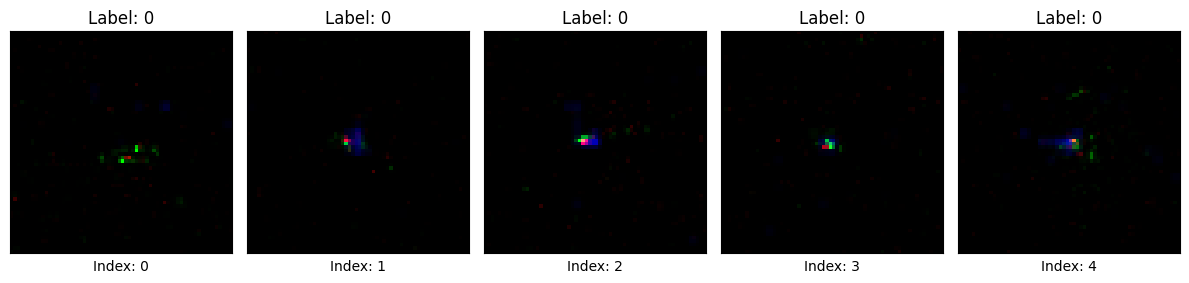

In [16]:
imagenes_ejemplo = np.stack([train_dataset[i][0].numpy() for i in range(5)])
etiquetas_ejemplo = [train_dataset[i][1] for i in range(5)]
ejemplo_imagenes(imagenes_ejemplo, etiquetas_ejemplo)

## Variational Autoencoder (VAE)

The VAE compresses each $64 \times 64$ three-channel jet image into a $4 \times 16 \times 16$ latent representation. Because the detector images are highly sparse, the decoder estimates pixel occupancy and deposited intensity separately. The training objective combines reconstruction, occupancy, energy, peak-response, mask, false-positive, and KL-divergence terms.

In [17]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.norm1 = nn.GroupNorm(8, in_channels)
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
        )

        self.norm2 = nn.GroupNorm(8, out_channels)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
        )

        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1)
        )

    def forward(self, x):
        h = self.conv1(F.silu(self.norm1(x)))
        h = self.conv2(F.silu(self.norm2(h)))

        return h + self.skip(x)

In [18]:
class JetSpatialVAE16Occupancy(nn.Module):

    def __init__(
        self,
        in_channels=3,
        latent_channels=4,
        base_channels=64,

    ):
        super().__init__()

        self.latent_channels = latent_channels

        self.enc_in = nn.Conv2d(
            in_channels,
            base_channels,
            kernel_size=3,
            padding=1,
        )
        self.enc_block1 = ResBlock(base_channels, base_channels)

        self.down1 = nn.Conv2d(
            base_channels,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1,
        )
        self.enc_block2 = ResBlock(
            base_channels * 2,
            base_channels * 2,
        )

        self.down2 = nn.Conv2d(
            base_channels * 2,
            base_channels * 4,
            kernel_size=4,
            stride=2,
            padding=1,
        )
        self.enc_block3 = ResBlock(
            base_channels * 4,
            base_channels * 4,
        )

        self.enc_refine16 = nn.Conv2d(
            base_channels * 4,
            base_channels * 4,
            kernel_size=3,
            padding=1,
        )
        self.enc_mid = ResBlock(
            base_channels * 4,
            base_channels * 4,
        )

        self.to_moments = nn.Conv2d(
            base_channels * 4,
            2 * latent_channels,
            kernel_size=3,
            padding=1,
        )

        self.dec_in = nn.Conv2d(
            latent_channels,
            base_channels * 4,
            kernel_size=3,
            padding=1,
        )
        self.dec_mid = ResBlock(
            base_channels * 4,
            base_channels * 4,
        )

        self.dec_refine16 = nn.Sequential(
            nn.Conv2d(
                base_channels * 4,
                base_channels * 4,
                kernel_size=3,
                padding=1,
            ),
            ResBlock(
                base_channels * 4,
                base_channels * 4,
            ),
        )

        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(
                base_channels * 4,
                base_channels * 2,
                kernel_size=3,
                padding=1,
            ),
        )
        self.dec_block1 = ResBlock(
            base_channels * 2,
            base_channels * 2,
        )

        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(
                base_channels * 2,
                base_channels,
                kernel_size=3,
                padding=1,
            ),
        )
        self.dec_block2 = ResBlock(
            base_channels,
            base_channels,
        )

        self.out_norm = nn.GroupNorm(8, base_channels)

        self.mask_refine = ResBlock(
            base_channels,
            base_channels,
        )

        self.intensity_refine = ResBlock(
            base_channels,
            base_channels,
        )

        self.mask_head = nn.Conv2d(
            base_channels,
            in_channels,
            kernel_size=3,
            padding=1,
        )
        self.intensity_head = nn.Conv2d(
            base_channels,
            in_channels,
            kernel_size=3,
            padding=1,
        )

        nn.init.zeros_(self.mask_head.weight)
        nn.init.zeros_(self.intensity_head.weight)

        mask_prior = 0.01
        mask_bias = np.log(mask_prior / (1.0 - mask_prior))
        nn.init.constant_(self.mask_head.bias, float(mask_bias))

        nn.init.constant_(self.intensity_head.bias, -2.0)

    def encode(self, x):
        h = self.enc_block1(self.enc_in(x))
        h = self.enc_block2(self.down1(h))
        h = self.enc_block3(self.down2(h))
        h = self.enc_refine16(h)
        h = self.enc_mid(h)

        mu, log_var = torch.chunk(
            self.to_moments(h),
            chunks=2,
            dim=1,
        )

        log_var = torch.clamp(
            log_var,
            min=-10.0,
            max=8.0,
        )

        return mu, log_var

    @staticmethod
    def reparameterize(mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + torch.randn_like(std) * std

    def decode_components(self, z):
        h = self.dec_mid(self.dec_in(z))
        h = self.dec_refine16(h)
        h = self.dec_block1(self.up1(h))
        h = self.dec_block2(self.up2(h))

        features = F.silu(self.out_norm(h))

        mask_features = self.mask_refine(features)
        intensity_features = self.intensity_refine(features)
        mask_logits = self.mask_head(mask_features)
        intensity_logits = self.intensity_head(intensity_features)

        mask_probability = torch.sigmoid(mask_logits)
        intensity_01 = torch.sigmoid(intensity_logits)

        reconstruction_01 = mask_probability * intensity_01
        reconstruction = 2.0 * reconstruction_01 - 1.0

        return (
            reconstruction,
            mask_logits,
            mask_probability,
            intensity_01,
        )

    def decode(self, z):
        reconstruction, _, _, _ = self.decode_components(z)
        return reconstruction

    def decode_hard(
        self,
        z,
    ):
        _, _, mask_probability, intensity_01 = (
            self.decode_components(z)
        )

        channel_thresholds = get_occupancy_thresholds(
            mask_probability
        )

        hard_mask = (
            mask_probability > channel_thresholds
        ).to(intensity_01.dtype)

        reconstruction_01 = hard_mask * intensity_01

        return 2.0 * reconstruction_01 - 1.0

    def forward(
        self,
        x,
        deterministic=False,
        return_components=False,
    ):
        mu, log_var = self.encode(x)

        z = (
            mu
            if deterministic
            else self.reparameterize(mu, log_var)
        )

        (
            reconstruction,
            mask_logits,
            mask_probability,
            intensity_01,
        ) = self.decode_components(z)

        if return_components:
            return (
                reconstruction,
                mu,
                log_var,
                z,
                mask_logits,
                mask_probability,
                intensity_01,
            )

        return reconstruction, mu, log_var, z

In [ ]:
model_test = JetSpatialVAE16Occupancy(in_channels=3, latent_channels=LATENT_CHANNELS, base_channels=BASE_CHANNELS).to(device)
with torch.no_grad():
    output = model_test(images_batch[:2].to(device), deterministic=False, return_components=True)
reconstruction_test, mu_test, log_var_test, z_test, mask_logits_test, mask_probability_test, intensity_test = output

print('Entrada:', images_batch[:2].shape)
print('Latente:', z_test.shape)
print('Reconstrucción:', reconstruction_test.shape)
print('Máscara:', mask_probability_test.shape)
print('Intensidad:', intensity_test.shape)
print('Parámetros:', f'{sum((parameter.numel() for parameter in model_test.parameters())):,}')

Entrada: torch.Size([2, 3, 64, 64])
Latente: torch.Size([2, 4, 16, 16])
Reconstrucción: torch.Size([2, 3, 64, 64])
Máscara: torch.Size([2, 3, 64, 64])
Intensidad: torch.Size([2, 3, 64, 64])
Parámetros: 7,850,574


In [20]:
def masked_mean(values, mask, eps=1e-08):
    return (values * mask).sum() / (mask.sum() + eps)

def jet_vae_loss(
    reconstruction, target, mu, log_var, mask_logits, mask_probability, intensity_01, beta, active_thr_01=0.0001,
    active_weight=5.0, background_weight=1.0, energy_weight=1.0, background_energy_weight=0.01, mask_weight=0.1,
    occupancy_weight=2.0, false_positive_weight=0.5, peak_weight=1.0, occupancy_threshold=0.8,
    gate_temperature=0.05, topk_peak_pixels=8,
):
    target_01 = ((target + 1.0) / 2.0).clamp(0.0, 1.0)
    active_mask = (target_01 > active_thr_01).to(target_01.dtype)
    background_mask = 1.0 - active_mask
    intensity_absolute_error = torch.abs(intensity_01 - target_01)
    intensity_pixel_weight = 1.0 + 4.0 * target_01.square()
    active_intensity_loss = masked_mean(intensity_pixel_weight * intensity_absolute_error, active_mask)
    soft_gate = torch.sigmoid((mask_probability - occupancy_threshold) / gate_temperature)
    predicted_01 = soft_gate * intensity_01
    background_l1 = masked_mean(predicted_01, background_mask)
    reconstruction_loss = active_weight * active_intensity_loss + background_weight * background_l1
    predicted_active_fraction = soft_gate.mean(dim=(-2, -1))
    target_active_fraction = active_mask.mean(dim=(-2, -1))
    occupancy_loss = F.l1_loss(predicted_active_fraction, target_active_fraction)
    false_positive_loss = masked_mean(soft_gate, background_mask)
    predicted_energy = predicted_01.sum(dim=(-2, -1))
    target_energy = target_01.sum(dim=(-2, -1))
    energy_loss = F.smooth_l1_loss(torch.log1p(predicted_energy), torch.log1p(target_energy))
    false_background_energy = (predicted_01 * background_mask).sum(dim=(-2, -1))
    background_energy_loss = torch.log1p(false_background_energy).mean()
    positive_count = active_mask.sum(dim=(0, 2, 3))
    negative_count = background_mask.sum(dim=(0, 2, 3))
    positive_weight = torch.sqrt(negative_count / positive_count.clamp_min(1.0)).clamp(min=1.0, max=6.0)
    positive_weight = positive_weight.view(1, -1, 1, 1).detach()
    mask_loss = F.binary_cross_entropy_with_logits(mask_logits, active_mask, pos_weight=positive_weight)
    num_pixels = target_01.shape[-2] * target_01.shape[-1]
    k = min(topk_peak_pixels, num_pixels)
    predicted_topk = predicted_01.flatten(start_dim=2).topk(k, dim=-1).values.mean(dim=-1)
    target_topk = target_01.flatten(start_dim=2).topk(k, dim=-1).values.mean(dim=-1)
    predicted_maximum = predicted_01.amax(dim=(-2, -1))
    target_maximum = target_01.amax(dim=(-2, -1))
    topk_loss = F.l1_loss(predicted_topk, target_topk)
    maximum_loss = F.l1_loss(predicted_maximum, target_maximum)
    peak_loss = 0.5 * topk_loss + 0.5 * maximum_loss
    kl_loss = 0.5 * (mu.square() + log_var.exp() - 1.0 - log_var).mean()
    total_loss = (
        reconstruction_loss
        + energy_weight * energy_loss
        + background_energy_weight * background_energy_loss
        + mask_weight * mask_loss
        + occupancy_weight * occupancy_loss
        + false_positive_weight * false_positive_loss
        + peak_weight * peak_loss
        + beta * kl_loss
    )
    components = {
        'loss': total_loss,
        'reconstruction': reconstruction_loss,
        'active_l1': active_intensity_loss,
        'background_l1': background_l1,
        'energy': energy_loss,
        'background_energy': background_energy_loss,
        'mask_bce': mask_loss,
        'occupancy': occupancy_loss,
        'false_positive': false_positive_loss,
        'peak': peak_loss,
        'maximum': maximum_loss,
        'kl': kl_loss,
    }
    return (total_loss, components)

In [21]:
def accumulate_metrics(metric_sums, components, batch_size):
    for key, value in components.items():
        metric_sums[key] = metric_sums.get(key, 0.0) + value.detach().item() * batch_size

def average_metrics(metric_sums, n_examples):
    return {key: value / max(n_examples, 1) for key, value in metric_sums.items()}

def beta_for_epoch(epoch, beta_max, kl_start_epoch, kl_warmup_epochs):
    if epoch < kl_start_epoch:
        return 0.0
    progress = min(1.0, (epoch - kl_start_epoch + 1) / max(kl_warmup_epochs, 1))
    return beta_max * progress

@torch.no_grad()
def evaluate_vae_epoch(model, data_loader, beta, device):
    model.eval()
    totals = {}
    n_examples = 0
    for images, _ in data_loader:
        images = images.to(device)
        reconstruction, mu, log_var, _, mask_logits, mask_probability, intensity_01 = model(images, deterministic=True, return_components=True)
        _, components = jet_vae_loss(
            reconstruction=reconstruction, target=images, mu=mu, log_var=log_var, mask_logits=mask_logits,
            mask_probability=mask_probability, intensity_01=intensity_01, beta=beta,
            active_thr_01=ACTIVE_THRESHOLD_01, active_weight=ACTIVE_WEIGHT, background_weight=BACKGROUND_WEIGHT,
            energy_weight=ENERGY_WEIGHT, background_energy_weight=BACKGROUND_ENERGY_WEIGHT,
            mask_weight=MASK_WEIGHT, occupancy_weight=OCCUPANCY_WEIGHT,
            false_positive_weight=FALSE_POSITIVE_WEIGHT, peak_weight=PEAK_WEIGHT,
            occupancy_threshold=OCCUPANCY_THRESHOLD, gate_temperature=GATE_TEMPERATURE,
            topk_peak_pixels=TOPK_PEAK_PIXELS,
        )
        batch_size = images.size(0)
        accumulate_metrics(totals, components, batch_size)
        n_examples += batch_size
    return average_metrics(totals, n_examples)

def train_jet_vae(
    train_loader, val_loader, device, num_epochs=20, learning_rate=0.0002, patience=12,
    checkpoint_path='vae_latest_checkpoint.pt', best_model_path='vae_best_model.pt', resume_from=None,
):
    model = JetSpatialVAE16Occupancy(in_channels=3, latent_channels=LATENT_CHANNELS, base_channels=BASE_CHANNELS).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.0001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-06)
    history = {'train': [], 'val': [], 'beta': [], 'lr': []}
    best_validation_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0
    start_epoch = 0
    if resume_from is not None:
        checkpoint = torch.load(resume_from, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        history = checkpoint['history']
        best_validation_loss = checkpoint['best_validation_loss']
        epochs_without_improvement = checkpoint['epochs_without_improvement']
        start_epoch = checkpoint['epoch'] + 1
        print(f'VAE restaurado desde época {start_epoch}. Continuando en época {start_epoch + 1}.')
    for epoch in range(start_epoch, num_epochs):
        beta = beta_for_epoch(epoch=epoch, beta_max=BETA_MAX, kl_start_epoch=KL_START_EPOCH, kl_warmup_epochs=KL_WARMUP_EPOCHS)
        model.train()
        totals = {}
        n_examples = 0
        for images, _ in train_loader:
            images = images.to(device)
            optimizer.zero_grad(set_to_none=True)
            reconstruction, mu, log_var, _, mask_logits, mask_probability, intensity_01 = model(images, deterministic=False, return_components=True)
            loss, components = jet_vae_loss(
                reconstruction=reconstruction, target=images, mu=mu, log_var=log_var, mask_logits=mask_logits,
                mask_probability=mask_probability, intensity_01=intensity_01, beta=beta,
                active_thr_01=ACTIVE_THRESHOLD_01, active_weight=ACTIVE_WEIGHT,
                background_weight=BACKGROUND_WEIGHT, energy_weight=ENERGY_WEIGHT,
                background_energy_weight=BACKGROUND_ENERGY_WEIGHT, mask_weight=MASK_WEIGHT,
                occupancy_weight=OCCUPANCY_WEIGHT, false_positive_weight=FALSE_POSITIVE_WEIGHT,
                peak_weight=PEAK_WEIGHT, occupancy_threshold=OCCUPANCY_THRESHOLD,
                gate_temperature=GATE_TEMPERATURE, topk_peak_pixels=TOPK_PEAK_PIXELS,
            )
            if not torch.isfinite(loss):
                raise RuntimeError(f'Loss no finita en época {epoch + 1}: {loss.item()}')
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_size = images.size(0)
            accumulate_metrics(totals, components, batch_size)
            n_examples += batch_size
        train_metrics = average_metrics(totals, n_examples)
        validation_metrics = evaluate_vae_epoch(model=model, data_loader=val_loader, beta=beta, device=device)
        scheduler.step(validation_metrics['loss'])
        current_lr = optimizer.param_groups[0]['lr']
        history['train'].append(train_metrics)
        history['val'].append(validation_metrics)
        history['beta'].append(beta)
        history['lr'].append(current_lr)
        print(
            f"Epoch {epoch + 1:03d}/{num_epochs} | "
            f"beta={beta:.2e} | "
            f"lr={current_lr:.2e} | "
            f"train={train_metrics['loss']:.6f} | "
            f"val={validation_metrics['loss']:.6f} | "
            f"active={validation_metrics['active_l1']:.6f} | "
            f"bg={validation_metrics['background_l1']:.6f} | "
            f"energy={validation_metrics['energy']:.6f} | "
            f"occupancy={validation_metrics['occupancy']:.6f} | "
            f"false_pos={validation_metrics['false_positive']:.6f} | "
            f"peak={validation_metrics['peak']:.6f} | "
            f"max={validation_metrics['maximum']:.6f} | "
            f"mask={validation_metrics['mask_bce']:.6f} | "
            f"KL={validation_metrics['kl']:.6f}"
        )
        if validation_metrics['loss'] < best_validation_loss - 1e-06:
            best_validation_loss = validation_metrics['loss']
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
            torch.save({'epoch': epoch, 'model_state_dict': best_state, 'validation_loss': best_validation_loss}, best_model_path)
            print(f' Nuevo mejor VAE guardado (val={best_validation_loss:.6f})')
        else:
            epochs_without_improvement += 1
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'history': history,
                'best_validation_loss': best_validation_loss,
                'epochs_without_improvement': epochs_without_improvement,
            },
            checkpoint_path,
        )
        if epochs_without_improvement >= patience:
            print(f'Early stopping en época {epoch + 1}. Mejor val loss: {best_validation_loss:.6f}')
            break
    if os.path.exists(best_model_path):
        best_checkpoint = torch.load(best_model_path, map_location=device)
        model.load_state_dict(best_checkpoint['model_state_dict'])
        best_validation_loss = best_checkpoint['validation_loss']
        print(f'\nMejor VAE restaurado: val={best_validation_loss:.6f}')
    elif best_state is not None:
        model.load_state_dict(best_state)
    return (model.to(device), history)

In [22]:
vae_model = JetSpatialVAE16Occupancy(in_channels=3, latent_channels=LATENT_CHANNELS, base_channels=BASE_CHANNELS).to(device)
vae_best_checkpoint = torch.load('vae_best_model.pt', map_location=device)
vae_model.load_state_dict(vae_best_checkpoint['model_state_dict'])
vae_model.eval()
for parameter in vae_model.parameters():
    parameter.requires_grad_(False)
vae_latest_checkpoint = torch.load('vae_latest_checkpoint.pt', map_location='cpu')
vae_history = vae_latest_checkpoint['history']
print('VAE cargado | epoch:', vae_best_checkpoint['epoch'] + 1, '| val:', vae_best_checkpoint['validation_loss'])

VAE cargado | epoch: 12 | val: 0.09055950619488932


In [23]:
vae_model, vae_history = train_jet_vae(
    train_loader=train_loader, val_loader=val_loader, device=device, num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE, patience=12, checkpoint_path='vae_latest_checkpoint.pt',
    best_model_path='vae_best_model.pt', resume_from=None,
)

Epoch 001/12 | beta=0.00e+00 | lr=2.00e-04 | train=0.349717 | val=0.209023 | active=0.022149 | bg=0.000363 | energy=0.003782 | occupancy=0.004788 | false_pos=0.019956 | peak=0.042350 | max=0.053619 | mask=0.244545 | KL=460.770862
 Nuevo mejor VAE guardado (val=0.209023)
Epoch 002/12 | beta=0.00e+00 | lr=2.00e-04 | train=0.184089 | val=0.167550 | active=0.017866 | bg=0.000221 | energy=0.005374 | occupancy=0.004222 | false_pos=0.014476 | peak=0.033534 | max=0.038807 | mask=0.179767 | KL=1156.114098
 Nuevo mejor VAE guardado (val=0.167550)
Epoch 003/12 | beta=0.00e+00 | lr=2.00e-04 | train=0.152867 | val=0.146550 | active=0.015773 | bg=0.000190 | energy=0.003955 | occupancy=0.005056 | false_pos=0.013399 | peak=0.025931 | max=0.031504 | mask=0.159104 | KL=1769.947119
 Nuevo mejor VAE guardado (val=0.146550)
Epoch 004/12 | beta=1.11e-04 | lr=2.00e-04 | train=0.142641 | val=0.139828 | active=0.014618 | bg=0.000237 | energy=0.001827 | occupancy=0.004583 | false_pos=0.015634 | peak=0.025151 | 

In [24]:
@torch.no_grad()
def calibrate_occupancy_thresholds(model, data_loader, device):
    model.eval()
    probability_batches = [[], [], []]
    target_mask_batches = [[], [], []]
    for images, _ in data_loader:
        images = images.to(device)
        _, _, _, _, _, mask_probability, _ = model(images, deterministic=True, return_components=True)
        target_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        target_mask = target_01 > ACTIVE_THRESHOLD_01
        for channel_index in range(3):
            probability_batches[channel_index].append(mask_probability[:, channel_index, :, :].detach().cpu().flatten())
            target_mask_batches[channel_index].append(target_mask[:, channel_index, :, :].detach().cpu().flatten())
    selected_thresholds = []
    results = []
    for channel_index, channel_name in enumerate(CHANNEL_NAMES):
        probabilities = torch.cat(probability_batches[channel_index])
        target_mask = torch.cat(target_mask_batches[channel_index]).bool()
        real_active_fraction = target_mask.float().mean().item()
        quantile_value = 1.0 - real_active_fraction
        MAX_QUANTILE_SAMPLES = 5000000
        if probabilities.numel() > MAX_QUANTILE_SAMPLES:
            generator = torch.Generator()
            generator.manual_seed(SEED + channel_index)
            sampled_indices = torch.randint(low=0, high=probabilities.numel(), size=(MAX_QUANTILE_SAMPLES,), generator=generator)
            probabilities_for_quantile = probabilities[sampled_indices]
        else:
            probabilities_for_quantile = probabilities
        selected_threshold = torch.quantile(probabilities_for_quantile, quantile_value).item()
        predicted_mask = probabilities > selected_threshold
        predicted_active_fraction = predicted_mask.float().mean().item()
        true_positive = (predicted_mask & target_mask).sum().item()
        false_positive = (predicted_mask & ~target_mask).sum().item()
        false_negative = (~predicted_mask & target_mask).sum().item()
        precision = true_positive / max(true_positive + false_positive, 1)
        recall = true_positive / max(true_positive + false_negative, 1)
        iou = true_positive / max(true_positive + false_positive + false_negative, 1)
        selected_thresholds.append(selected_threshold)
        results.append({
            'Channel': channel_name,
            'Threshold': selected_threshold,
            'Real active fraction': real_active_fraction,
            'Predicted active fraction': predicted_active_fraction,
            'Precision': precision,
            'Recall': recall,
            'IoU': iou,
        })
    thresholds_tensor = torch.tensor(selected_thresholds, dtype=torch.float32)
    results_dataframe = pd.DataFrame(results)
    return (thresholds_tensor, results_dataframe)

In [25]:
OCCUPANCY_THRESHOLDS, occupancy_calibration_results = calibrate_occupancy_thresholds(model=vae_model, data_loader=val_loader, device=device)
print('Thresholds calibrados en validation:')
for channel_name, threshold in zip(CHANNEL_NAMES, OCCUPANCY_THRESHOLDS.tolist()):
    print(f'{channel_name:8s}: {threshold:.6f}')
print()
display(occupancy_calibration_results.round(6))

Thresholds calibrados en validation:
TRACKER : 0.806919
ECAL    : 0.790168
HCAL    : 0.787369



,Channel,Threshold,Real active fraction,Predicted active fraction,Precision,Recall,IoU
0,TRACKER,0.806919,0.041525,0.041405,0.715842,0.713786,0.556193
1,ECAL,0.790168,0.052989,0.053116,0.721084,0.722812,0.564880
2,HCAL,0.787369,0.044736,0.044804,0.972990,0.974470,0.948804


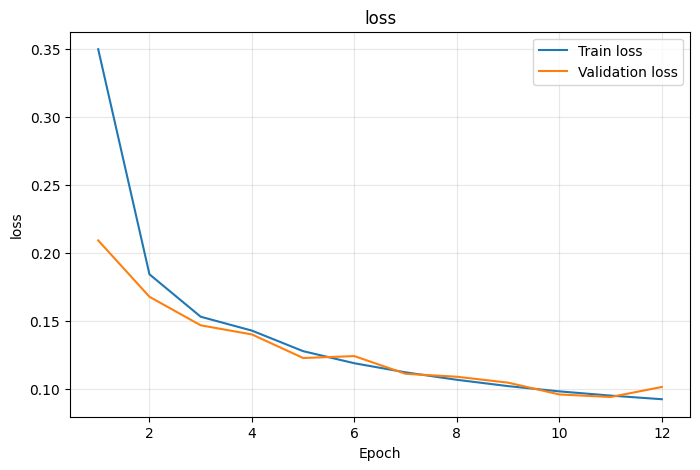

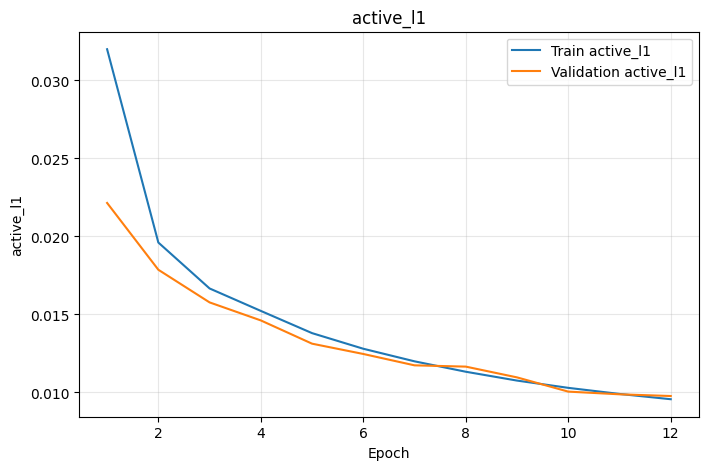

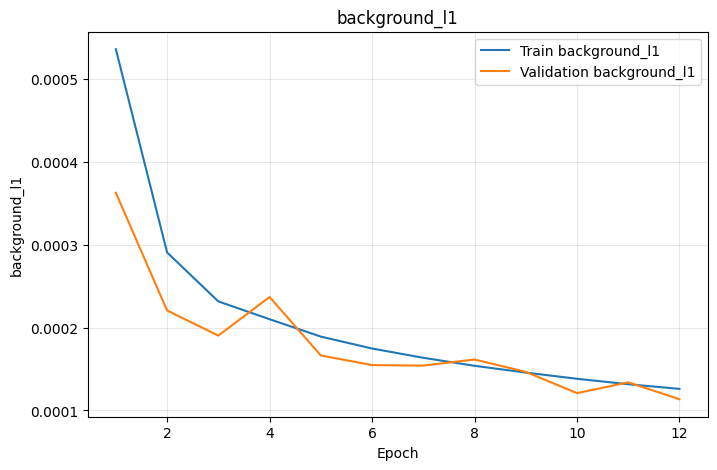

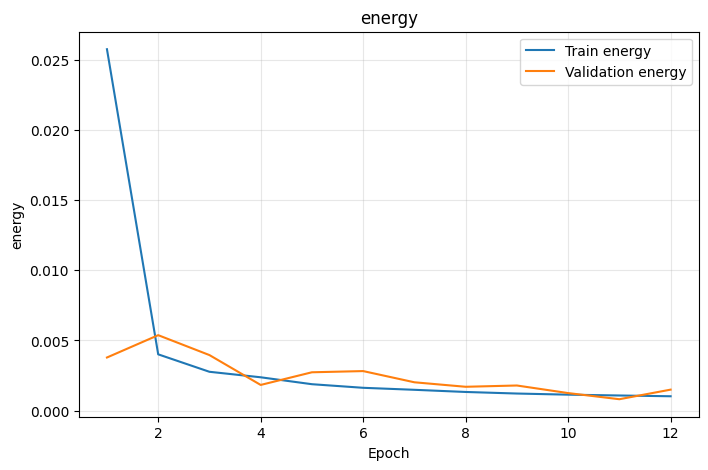

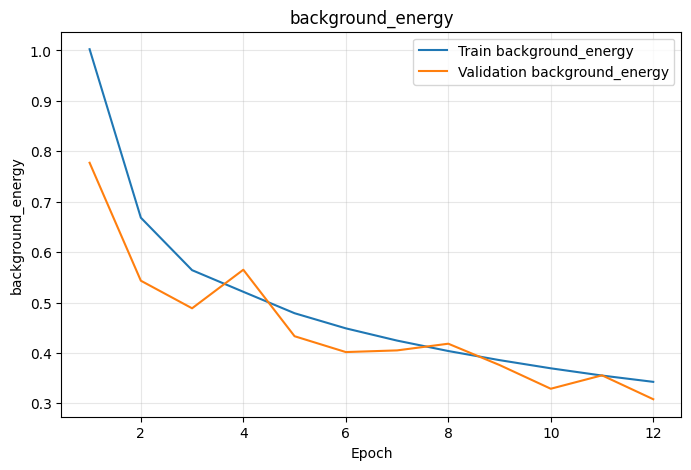

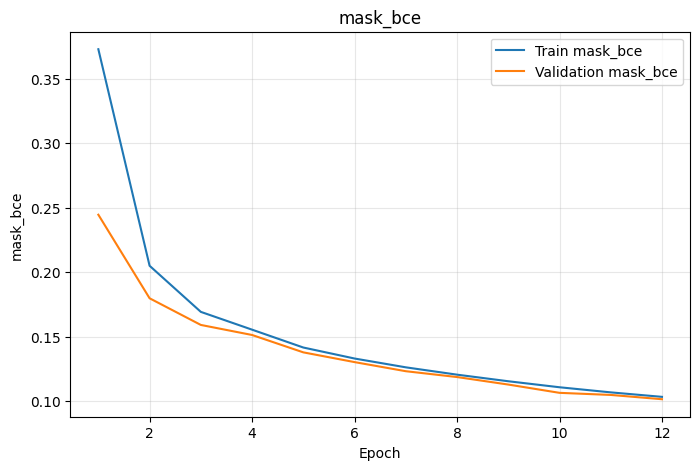

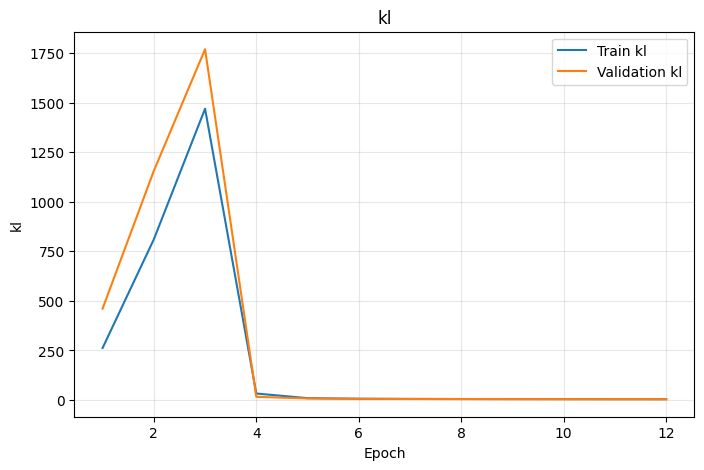

In [26]:
def plot_training_history(history):
    epochs = np.arange(1, len(history['train']) + 1)
    metrics = ['loss', 'active_l1', 'background_l1', 'energy', 'background_energy', 'mask_bce', 'kl']
    for metric in metrics:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, [item[metric] for item in history['train']], label=f'Train {metric}')
        plt.plot(epochs, [item[metric] for item in history['val']], label=f'Validation {metric}')
        plt.xlabel('Epoch')
        plt.ylabel(metric)
        plt.title(metric)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()
plot_training_history(vae_history)

In [27]:
def wasserstein_xy_per_channel(reconstruction, target, eps=1e-08):
    projection_x_reconstruction = reconstruction.sum(dim=2)
    projection_x_target = target.sum(dim=2)
    projection_y_reconstruction = reconstruction.sum(dim=3)
    projection_y_target = target.sum(dim=3)
    px_reconstruction = projection_x_reconstruction / (projection_x_reconstruction.sum(dim=-1, keepdim=True) + eps)
    px_target = projection_x_target / (projection_x_target.sum(dim=-1, keepdim=True) + eps)
    py_reconstruction = projection_y_reconstruction / (projection_y_reconstruction.sum(dim=-1, keepdim=True) + eps)
    py_target = projection_y_target / (projection_y_target.sum(dim=-1, keepdim=True) + eps)
    w1_x = torch.abs(torch.cumsum(px_reconstruction, dim=-1) - torch.cumsum(px_target, dim=-1)).sum(dim=-1)
    w1_y = torch.abs(torch.cumsum(py_reconstruction, dim=-1) - torch.cumsum(py_target, dim=-1)).sum(dim=-1)
    return (w1_x + w1_y).mean()

@torch.no_grad()
def evaluate_reconstructions(model, data_loader, device, hard_reconstruction=False):
    model.eval()
    totals = {
        'mae_01': 0.0,
        'mse_01': 0.0,
        'active_mae_01': 0.0,
        'background_mae_01': 0.0,
        'energy_relative_error': 0.0,
        'w1_xy': 0.0,
        'ssim': 0.0,
        'active_frac_real': 0.0,
        'active_frac_recon': 0.0,
    }
    n_examples = 0
    for images, _ in data_loader:
        images = images.to(device)
        reconstruction, _, _, _, _, mask_probability, intensity_01 = model(images, deterministic=True, return_components=True)
        images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        if not hard_reconstruction:
            reconstruction_01 = ((reconstruction + 1.0) / 2.0).clamp(0.0, 1.0)
        else:
            channel_thresholds = get_occupancy_thresholds(mask_probability)
            hard_mask = (mask_probability > channel_thresholds).to(images.dtype)
            reconstruction_01 = hard_mask * intensity_01
        active_mask = (images_01 > ACTIVE_THRESHOLD_01).to(images.dtype)
        background_mask = 1.0 - active_mask
        absolute_error = torch.abs(reconstruction_01 - images_01)
        true_energy = images_01.sum(dim=(1, 2, 3))
        reconstructed_energy = reconstruction_01.sum(dim=(1, 2, 3))
        batch_metrics = {
            'mae_01': absolute_error.mean(),
            'mse_01': F.mse_loss(reconstruction_01, images_01),
            'active_mae_01': masked_mean(absolute_error, active_mask),
            'background_mae_01': masked_mean(absolute_error, background_mask),
            'energy_relative_error': (torch.abs(reconstructed_energy - true_energy) / true_energy.clamp_min(1e-08)).mean(),
            'w1_xy': wasserstein_xy_per_channel(reconstruction_01, images_01),
            'ssim': ssim(reconstruction_01, images_01, data_range=1.0, size_average=True),
            'active_frac_real': active_mask.mean(),
            'active_frac_recon': (reconstruction_01 > ACTIVE_THRESHOLD_01).float().mean(),
        }
        batch_size = images.size(0)
        for key, value in batch_metrics.items():
            totals[key] += value.item() * batch_size
        n_examples += batch_size
    return {key: value / n_examples for key, value in totals.items()}

In [28]:
soft_metrics = evaluate_reconstructions(model=vae_model, data_loader=test_loader, device=device, hard_reconstruction=False)
hard_metrics = evaluate_reconstructions(model=vae_model, data_loader=test_loader, device=device, hard_reconstruction=True)
print('RECONSTRUCCIÓN SUAVE')
for key, value in soft_metrics.items():
    print(f'{key:28s}: {value:.8f}')
print('\nRECONSTRUCCIÓN HARD — thresholds por canal')
for key, value in hard_metrics.items():
    print(f'{key:28s}: {value:.8f}')

RECONSTRUCCIÓN SUAVE
mae_01                      : 0.00076881
mse_01                      : 0.00003533
active_mae_01               : 0.00873982
background_mae_01           : 0.00037864
energy_relative_error       : 0.16313170
w1_xy                       : 1.20133570
ssim                        : 0.98823161
active_frac_real            : 0.04659341
active_frac_recon           : 0.15118796

RECONSTRUCCIÓN HARD — thresholds por canal
mae_01                      : 0.00057354
mse_01                      : 0.00003644
active_mae_01               : 0.00954623
background_mae_01           : 0.00013421
energy_relative_error       : 0.02848504
w1_xy                       : 0.79901474
ssim                        : 0.99043945
active_frac_real            : 0.04659341
active_frac_recon           : 0.04659441


In [29]:
@torch.no_grad()
def evaluate_occupancy_head(model, data_loader, device):
    model.eval()
    true_positive = torch.zeros(3, device=device)
    false_positive = torch.zeros(3, device=device)
    false_negative = torch.zeros(3, device=device)
    predicted_active_sum = torch.zeros(3, device=device)
    real_active_sum = torch.zeros(3, device=device)
    probability_sum = torch.zeros(3, device=device)
    pixel_count = 0
    for images, _ in data_loader:
        images = images.to(device)
        _, _, _, _, _, mask_probability, _ = model(images, deterministic=True, return_components=True)
        target_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        true_mask = target_01 > ACTIVE_THRESHOLD_01
        channel_thresholds = get_occupancy_thresholds(mask_probability)
        predicted_mask = mask_probability > channel_thresholds
        true_positive += (predicted_mask & true_mask).sum(dim=(0, 2, 3))
        false_positive += (predicted_mask & ~true_mask).sum(dim=(0, 2, 3))
        false_negative += (~predicted_mask & true_mask).sum(dim=(0, 2, 3))
        predicted_active_sum += predicted_mask.float().sum(dim=(0, 2, 3))
        real_active_sum += true_mask.float().sum(dim=(0, 2, 3))
        probability_sum += mask_probability.sum(dim=(0, 2, 3))
        pixel_count += images.shape[0] * images.shape[-2] * images.shape[-1]
    precision = true_positive / (true_positive + false_positive).clamp_min(1.0)
    recall = true_positive / (true_positive + false_negative).clamp_min(1.0)
    iou = true_positive / (true_positive + false_positive + false_negative).clamp_min(1.0)
    return pd.DataFrame({
        'Canal': CHANNEL_NAMES,
        'Fracción activa real': (real_active_sum / pixel_count).cpu().numpy(),
        'Fracción activa máscara': (predicted_active_sum / pixel_count).cpu().numpy(),
        'Probabilidad media': (probability_sum / pixel_count).cpu().numpy(),
        'Precision': precision.cpu().numpy(),
        'Recall': recall.cpu().numpy(),
        'IoU': iou.cpu().numpy(),
    })
occupancy_results = evaluate_occupancy_head(model=vae_model, data_loader=test_loader, device=device)
display(occupancy_results.round(6))

,Canal,Fracción activa real,Fracción activa máscara,Probabilidad media,Precision,Recall,IoU
0,TRACKER,0.041582,0.041530,0.082341,0.714581,0.713692,0.555374
1,ECAL,0.053231,0.053251,0.090839,0.720370,0.720638,0.563115
2,HCAL,0.044967,0.045014,0.049070,0.972814,0.973829,0.948029


In [30]:
@torch.no_grad()
def show_reconstructions(model, data_loader, device, num_images=6, contrast=False, channel_order=(2, 0, 1)):
    model.eval()
    images, _ = next(iter(data_loader))
    images = images[:num_images].to(device)
    _, _, _, _, _, mask_probability, intensity_01 = model(images, deterministic=True, return_components=True)
    images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
    channel_thresholds = get_occupancy_thresholds(mask_probability)
    hard_mask = (mask_probability > channel_thresholds).to(images.dtype)
    reconstruction_01 = hard_mask * intensity_01
    images_01 = images_01.cpu()
    reconstruction_01 = reconstruction_01.cpu()
    fig, axes = plt.subplots(2, num_images, figsize=(2.8 * num_images, 5.5))
    for index in range(num_images):
        original = images_01[index][list(channel_order)]
        reconstruction = reconstruction_01[index][list(channel_order)]
        if contrast:
            active_values = original[original > 1e-06]
            vmax = torch.quantile(active_values, 0.99).item() if active_values.numel() else 1.0
            vmax = max(vmax, 1e-08)
            original_display = (original / vmax).clamp(0.0, 1.0)
            reconstruction_display = (reconstruction / vmax).clamp(0.0, 1.0)
        else:
            original_display = original
            reconstruction_display = reconstruction
        axes[0, index].imshow(original_display.permute(1, 2, 0).numpy(), origin='lower')
        axes[0, index].set_title(f'Original\nE={original.sum().item():.2f}')
        axes[0, index].axis('off')
        axes[1, index].imshow(reconstruction_display.permute(1, 2, 0).numpy(), origin='lower')
        axes[1, index].set_title(f'Reconstrucción\nE={reconstruction.sum().item():.2f}')
        axes[1, index].axis('off')
    plt.tight_layout()
    plt.show()

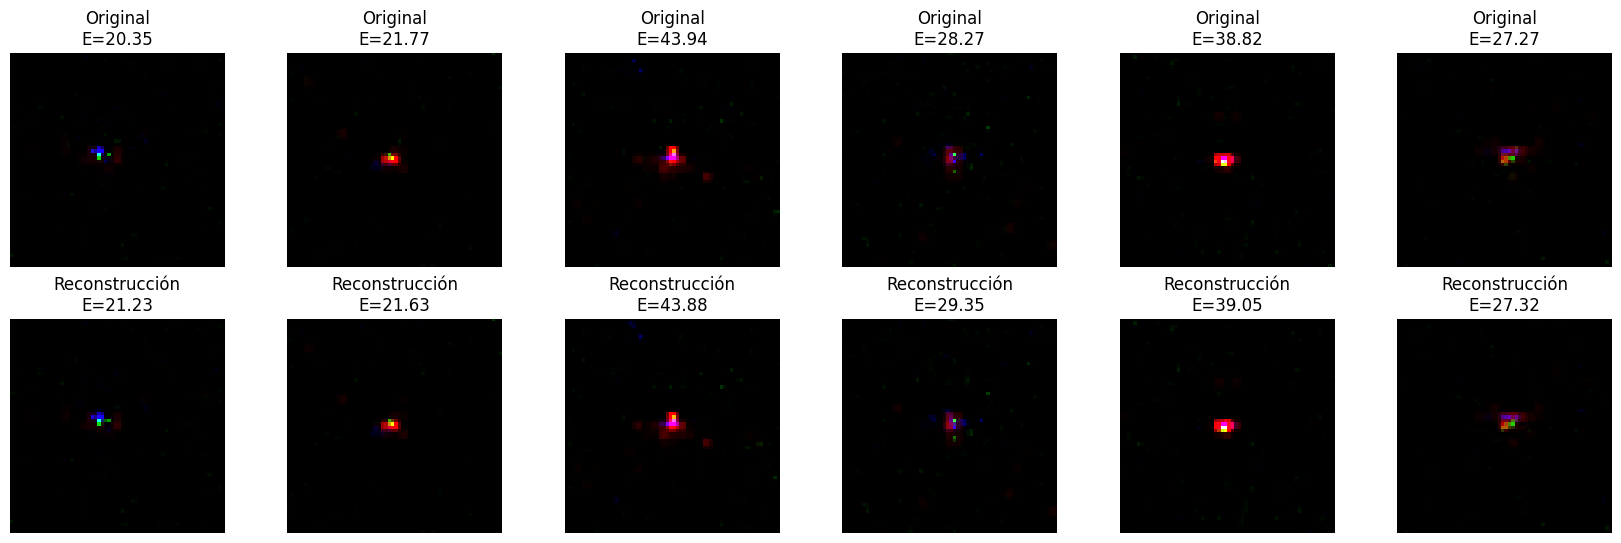

In [31]:
show_reconstructions(model=vae_model, data_loader=test_loader, device=device, contrast=False)

In [32]:
def empirical_w1(values_a, values_b):
    values_a = np.sort(np.asarray(values_a))
    values_b = np.sort(np.asarray(values_b))
    return np.mean(np.abs(values_a - values_b))

@torch.no_grad()
def collect_physics_diagnostics(model, data_loader, device, num_radial_bins=32):
    model.eval()
    energy_real_batches = []
    energy_recon_batches = []
    active_real_batches = []
    active_recon_batches = []
    max_real_batches = []
    max_recon_batches = []
    radial_real_sum = None
    radial_recon_sum = None
    radial_bin_index = None
    radial_centers = None
    for images, _ in data_loader:
        images = images.to(device)
        _, _, _, _, _, mask_probability, intensity_01 = model(images, deterministic=True, return_components=True)
        images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        channel_thresholds = get_occupancy_thresholds(mask_probability)
        hard_mask = (mask_probability > channel_thresholds).to(images.dtype)
        reconstruction_01 = hard_mask * intensity_01
        images_01 = images_01.cpu()
        reconstruction_01 = reconstruction_01.cpu()
        batch_size, channels, height, width = images_01.shape
        energy_real_batches.append(images_01.sum(dim=(-2, -1)).numpy())
        energy_recon_batches.append(reconstruction_01.sum(dim=(-2, -1)).numpy())
        active_real_batches.append((images_01 > ACTIVE_THRESHOLD_01).float().mean(dim=(-2, -1)).numpy())
        active_recon_batches.append((reconstruction_01 > ACTIVE_THRESHOLD_01).float().mean(dim=(-2, -1)).numpy())
        max_real_batches.append(images_01.amax(dim=(-2, -1)).numpy())
        max_recon_batches.append(reconstruction_01.amax(dim=(-2, -1)).numpy())
        if radial_bin_index is None:
            y, x = torch.meshgrid(torch.arange(height, dtype=torch.float32), torch.arange(width, dtype=torch.float32), indexing='ij')
            center_y = (height - 1) / 2.0
            center_x = (width - 1) / 2.0
            radius = torch.sqrt((y - center_y) ** 2 + (x - center_x) ** 2)
            radial_edges = torch.linspace(0.0, radius.max().item() + 1e-06, num_radial_bins + 1)
            radial_centers = (0.5 * (radial_edges[:-1] + radial_edges[1:])).numpy()
            radial_bin_index = (torch.bucketize(radius.reshape(-1), radial_edges, right=False) - 1).clamp(0, num_radial_bins - 1)
            radial_real_sum = torch.zeros(channels, num_radial_bins, dtype=torch.float64)
            radial_recon_sum = torch.zeros(channels, num_radial_bins, dtype=torch.float64)
        real_flat = images_01.reshape(batch_size, channels, -1).double()
        recon_flat = reconstruction_01.reshape(batch_size, channels, -1).double()
        for radial_bin in range(num_radial_bins):
            mask = radial_bin_index == radial_bin
            radial_real_sum[:, radial_bin] += real_flat[:, :, mask].sum(dim=(0, 2))
            radial_recon_sum[:, radial_bin] += recon_flat[:, :, mask].sum(dim=(0, 2))
    radial_real = (radial_real_sum / radial_real_sum.sum(dim=1, keepdim=True).clamp_min(1e-12)).numpy()
    radial_recon = (radial_recon_sum / radial_recon_sum.sum(dim=1, keepdim=True).clamp_min(1e-12)).numpy()
    return {
        'energy_real': np.concatenate(energy_real_batches),
        'energy_recon': np.concatenate(energy_recon_batches),
        'active_frac_real': np.concatenate(active_real_batches),
        'active_frac_recon': np.concatenate(active_recon_batches),
        'max_real': np.concatenate(max_real_batches),
        'max_recon': np.concatenate(max_recon_batches),
        'radial_centers': radial_centers,
        'radial_real': radial_real,
        'radial_recon': radial_recon,
    }

def summarize_physics_diagnostics(diagnostics):
    rows = []
    for channel, channel_name in enumerate(CHANNEL_NAMES):
        energy_real = diagnostics['energy_real'][:, channel]
        energy_recon = diagnostics['energy_recon'][:, channel]
        active_real = diagnostics['active_frac_real'][:, channel]
        active_recon = diagnostics['active_frac_recon'][:, channel]
        max_real = diagnostics['max_real'][:, channel]
        max_recon = diagnostics['max_recon'][:, channel]
        radial_real = diagnostics['radial_real'][channel]
        radial_recon = diagnostics['radial_recon'][channel]
        valid_energy = energy_real > 1e-06
        energy_relative_error = np.mean(np.abs(energy_recon[valid_energy] - energy_real[valid_energy]) / energy_real[valid_energy])
        energy_mean_real = energy_real.mean()
        energy_mean_recon = energy_recon.mean()
        rows.append({
            'Canal': channel_name,
            'E real media': energy_mean_real,
            'E recon media': energy_mean_recon,
            'Bias E (%)': 100.0 * (energy_mean_recon - energy_mean_real) / max(energy_mean_real, 1e-08),
            'Error relativo E (%)': 100.0 * energy_relative_error,
            'W1 energía': empirical_w1(energy_real, energy_recon),
            'Fracción activa real': active_real.mean(),
            'Fracción activa recon': active_recon.mean(),
            'Diferencia activa (p.p.)': 100.0 * (active_recon.mean() - active_real.mean()),
            'Máximo real medio': max_real.mean(),
            'Máximo recon medio': max_recon.mean(),
            'W1 máximo': empirical_w1(max_real, max_recon),
            'Radial L1': np.abs(radial_recon - radial_real).sum(),
            'Radial L2': np.sqrt(np.mean((radial_recon - radial_real) ** 2)),
        })
    return pd.DataFrame(rows)

In [33]:
diagnostics = collect_physics_diagnostics(model=vae_model, data_loader=test_loader, device=device, num_radial_bins=32)
physics_summary = summarize_physics_diagnostics(diagnostics)
display(physics_summary.round(6))

,Canal,E real media,E recon media,Bias E (%),Error relativo E (%),W1 energía,Fracción activa real,Fracción activa recon,Diferencia activa (p.p.),Máximo real medio,Máximo recon medio,W1 máximo,Radial L1,Radial L2
0,TRACKER,5.903112,6.023866,2.045603,5.180436,0.121975,0.041582,0.041527,-0.005411,0.761202,0.774404,0.013669,0.036190,0.002223
1,ECAL,7.761820,8.247360,6.255497,6.750694,0.489392,0.053231,0.053251,0.001973,0.827062,0.832656,0.006104,0.009739,0.000510
2,HCAL,11.560102,11.486447,-0.637149,1.765433,0.083496,0.044967,0.045005,0.003738,0.528693,0.533676,0.005334,0.010087,0.000506


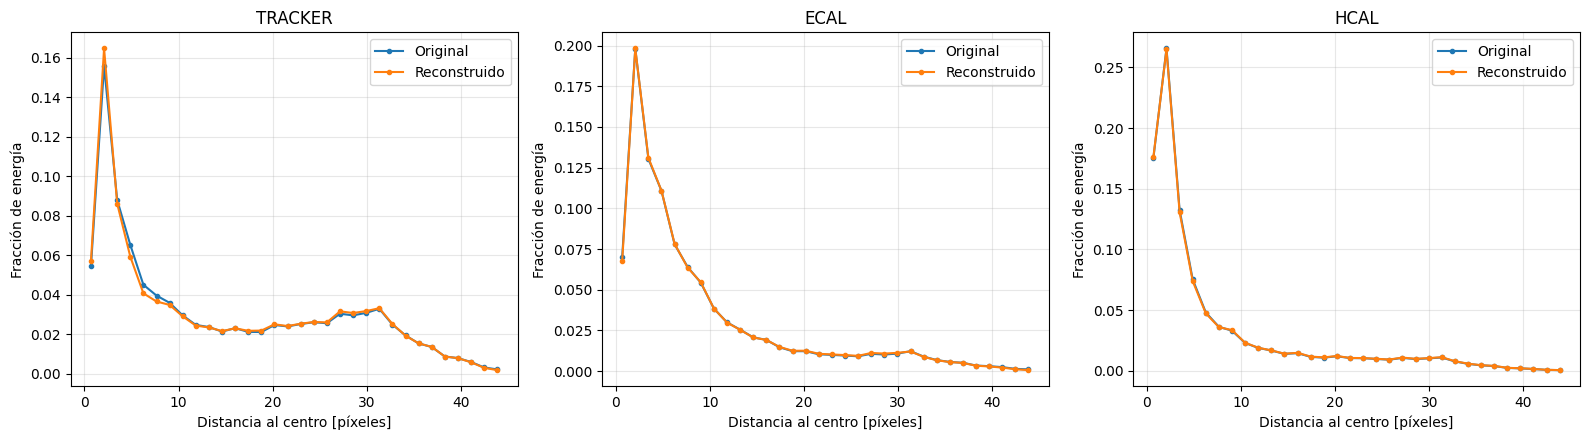

In [34]:
def plot_radial_profiles(diagnostics):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for channel, channel_name in enumerate(CHANNEL_NAMES):
        axes[channel].plot(diagnostics['radial_centers'], diagnostics['radial_real'][channel], marker='o', markersize=3, label='Original')
        axes[channel].plot(diagnostics['radial_centers'], diagnostics['radial_recon'][channel], marker='o', markersize=3, label='Reconstruido')
        axes[channel].set_title(channel_name)
        axes[channel].set_xlabel('Distancia al centro [píxeles]')
        axes[channel].set_ylabel('Fracción de energía')
        axes[channel].legend()
        axes[channel].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_radial_profiles(diagnostics)

In [35]:
def common_histogram_bins(real_values, reconstructed_values, num_bins=50, upper_quantile=0.999):
    if num_bins < 1:
        raise ValueError('num_bins debe ser al menos 1.')
    if not 0.0 < upper_quantile <= 1.0:
        raise ValueError('upper_quantile debe estar en (0,1].')
    real_values = np.asarray(real_values, dtype=np.float64).reshape(-1)
    reconstructed_values = np.asarray(reconstructed_values, dtype=np.float64).reshape(-1)
    combined = np.concatenate([real_values, reconstructed_values])
    combined = combined[np.isfinite(combined)]
    if combined.size == 0:
        raise ValueError('No hay valores finitos para construir el histograma.')
    lower = combined.min()
    upper = np.quantile(combined, upper_quantile)
    if upper <= lower:
        upper = lower + 1e-06
    return np.linspace(lower, upper, num_bins + 1)

In [36]:
def plot_integrated_intensity_distributions(diagnostics, num_bins=50, upper_quantile=0.999):
    energy_real = np.asarray(diagnostics['energy_real'])
    energy_recon = np.asarray(diagnostics['energy_recon'])
    if energy_real.shape != energy_recon.shape:
        raise ValueError('Los arreglos real y reconstruido deben tener la misma forma.')
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()
    total_real = energy_real.sum(axis=1)
    total_recon = energy_recon.sum(axis=1)
    bins = common_histogram_bins(total_real, total_recon, num_bins=num_bins, upper_quantile=upper_quantile)
    real_weights = np.full(total_real.shape, 100.0 / len(total_real))
    recon_weights = np.full(total_recon.shape, 100.0 / len(total_recon))
    axes[0].hist(total_real, bins=bins, weights=real_weights, histtype='step', linewidth=2, label='Original')
    axes[0].hist(total_recon, bins=bins, weights=recon_weights, histtype='step', linewidth=2, label='Reconstruido')
    axes[0].set_title('Intensidad integrada total')
    axes[0].set_xlabel('Suma de intensidades normalizadas')
    axes[0].set_ylabel('Eventos por intervalo (%)')
    axes[0].set_xlim(bins[0], bins[-1])
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    for channel, channel_name in enumerate(CHANNEL_NAMES):
        real_values = energy_real[:, channel]
        recon_values = energy_recon[:, channel]
        bins = common_histogram_bins(real_values, recon_values, num_bins=num_bins, upper_quantile=upper_quantile)
        real_weights = np.full(real_values.shape, 100.0 / len(real_values))
        recon_weights = np.full(recon_values.shape, 100.0 / len(recon_values))
        axis = axes[channel + 1]
        axis.hist(real_values, bins=bins, weights=real_weights, histtype='step', linewidth=2, label='Original')
        axis.hist(recon_values, bins=bins, weights=recon_weights, histtype='step', linewidth=2, label='Reconstruido')
        axis.set_title(f'Intensidad integrada: {channel_name}')
        axis.set_xlabel('Suma de intensidades normalizadas')
        axis.set_ylabel('Eventos por intervalo (%)')
        axis.set_xlim(bins[0], bins[-1])
        axis.legend()
        axis.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
    return (fig, axes)

In [37]:
def plot_channel_distributions(diagnostics, metric, num_bins=50, upper_quantile=1.0, class_name=None):
    if metric == 'energy':
        real_data = np.asarray(diagnostics['energy_real'])
        generated_data = np.asarray(diagnostics['energy_recon'])
        title_prefix = 'Energía integrada'
        x_label = 'Suma de intensidades normalizadas'
    elif metric == 'active_fraction':
        real_data = np.asarray(diagnostics['active_frac_real']) * 100.0
        generated_data = np.asarray(diagnostics['active_frac_recon']) * 100.0
        title_prefix = 'Fracción activa'
        x_label = 'Píxeles activos por jet (%)'
    elif metric == 'maximum':
        real_data = np.asarray(diagnostics['max_real'])
        generated_data = np.asarray(diagnostics['max_recon'])
        title_prefix = 'Intensidad máxima'
        x_label = 'Intensidad máxima normalizada'
    else:
        raise ValueError("metric debe ser 'energy', 'active_fraction' o 'maximum'.")
    if real_data.ndim != 2:
        raise ValueError('Los datos deben tener shape [N, C].')
    fig, axes = plt.subplots(1, len(CHANNEL_NAMES), figsize=(16, 4.5))
    for channel, channel_name in enumerate(CHANNEL_NAMES):
        real_values = real_data[:, channel]
        generated_values = generated_data[:, channel]
        bins = common_histogram_bins(real_values, generated_values, num_bins=num_bins, upper_quantile=upper_quantile)
        real_weights = np.full(real_values.shape, 100.0 / len(real_values))
        generated_weights = np.full(generated_values.shape, 100.0 / len(generated_values))
        axes[channel].hist(real_values, bins=bins, weights=real_weights, histtype='step', linewidth=2, label='Original')
        axes[channel].hist(generated_values, bins=bins, weights=generated_weights, histtype='step', linewidth=2, label='Generado')
        if class_name is None:
            title = f'{title_prefix}: {channel_name}'
        else:
            title = f'{title_prefix}: {channel_name} — {class_name}'
        axes[channel].set_title(title)
        axes[channel].set_xlabel(x_label)
        axes[channel].set_ylabel('Jets por intervalo (%)')
        axes[channel].set_xlim(bins[0], bins[-1])
        axes[channel].legend()
        axes[channel].grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
    return (fig, axes)

In [38]:
diagnostics = collect_physics_diagnostics(model=vae_model, data_loader=test_loader, device=device, num_radial_bins=32)

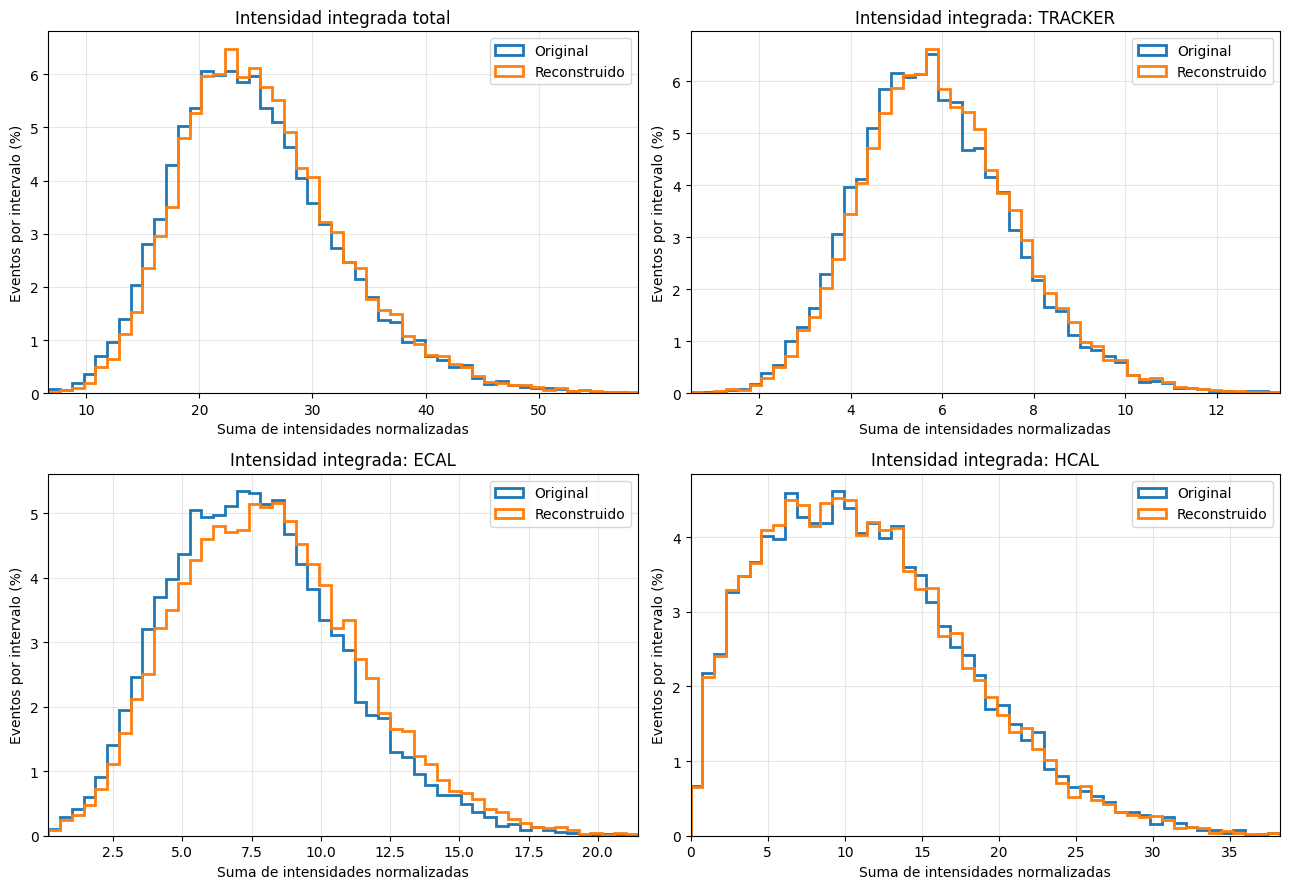

(<Figure size 1300x900 with 4 Axes>,
 array([<Axes: title={'center': 'Intensidad integrada total'}, xlabel='Suma de intensidades normalizadas', ylabel='Eventos por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad integrada: TRACKER'}, xlabel='Suma de intensidades normalizadas', ylabel='Eventos por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad integrada: ECAL'}, xlabel='Suma de intensidades normalizadas', ylabel='Eventos por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad integrada: HCAL'}, xlabel='Suma de intensidades normalizadas', ylabel='Eventos por intervalo (%)'>],
       dtype=object))

In [39]:
plot_integrated_intensity_distributions(diagnostics, num_bins=50, upper_quantile=0.999)

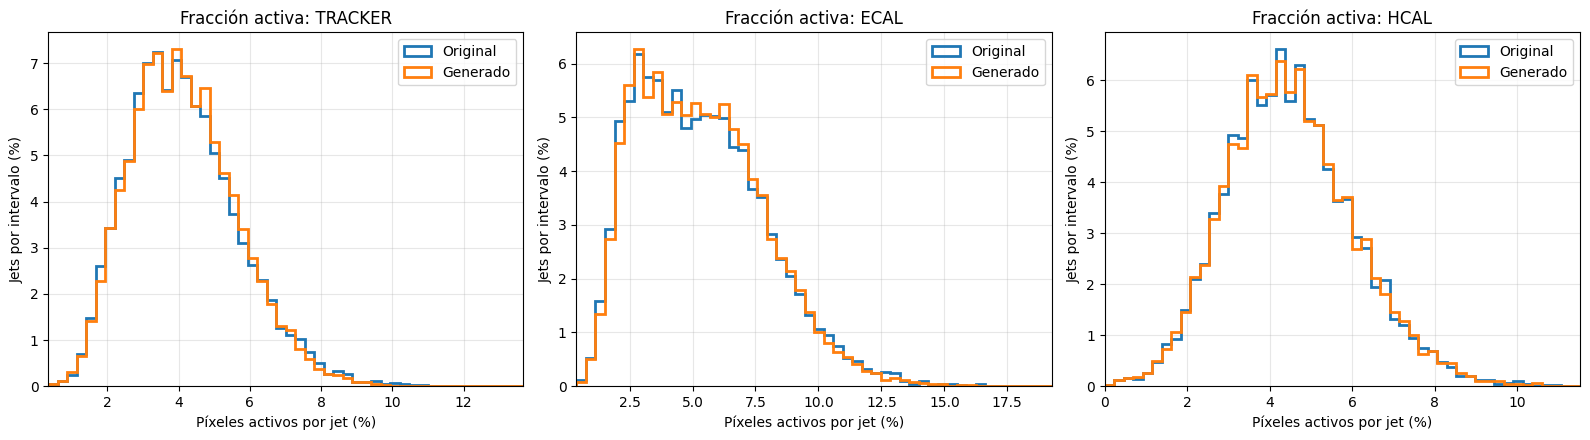

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Fracción activa: TRACKER'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: ECAL'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: HCAL'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [40]:
plot_channel_distributions(diagnostics, metric='active_fraction', num_bins=50)

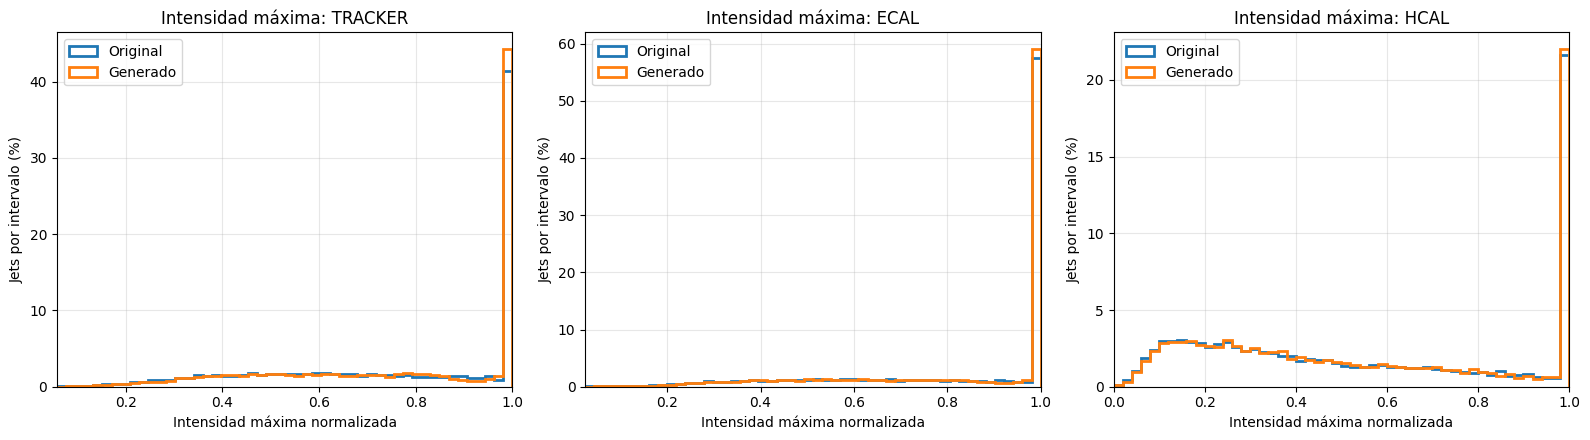

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Intensidad máxima: TRACKER'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: ECAL'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: HCAL'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [41]:
plot_channel_distributions(diagnostics, metric='maximum', num_bins=50, upper_quantile=1.0)

In [42]:
@torch.no_grad()
def inspect_vae_latents(model, data_loader, device):
    model.eval()
    mu_batches = []
    log_var_batches = []
    z_batches = []
    for images, _ in data_loader:
        images = images.to(device)
        mu, log_var = model.encode(images)
        z = model.reparameterize(mu, log_var)
        mu_batches.append(mu.cpu())
        log_var_batches.append(log_var.cpu())
        z_batches.append(z.cpu())
    mu_all = torch.cat(mu_batches)
    log_var_all = torch.cat(log_var_batches)
    z_all = torch.cat(z_batches)
    rows = []
    for channel in range(mu_all.shape[1]):
        rows.append({
            'Canal latente': channel,
            'mu media': mu_all[:, channel].mean().item(),
            'mu std': mu_all[:, channel].std().item(),
            'logvar media': log_var_all[:, channel].mean().item(),
            'logvar std': log_var_all[:, channel].std().item(),
            'z media': z_all[:, channel].mean().item(),
            'z std': z_all[:, channel].std().item(),
            'z mínimo': z_all[:, channel].min().item(),
            'z máximo': z_all[:, channel].max().item(),
        })
    global_stats = {
        'mu_mean': mu_all.mean().item(),
        'mu_std': mu_all.std().item(),
        'logvar_mean': log_var_all.mean().item(),
        'logvar_std': log_var_all.std().item(),
        'z_mean': z_all.mean().item(),
        'z_std': z_all.std().item(),
        'latent_shape': tuple(z_all.shape),
    }
    return (pd.DataFrame(rows), global_stats)
latent_channel_stats, latent_global_stats = inspect_vae_latents(model=vae_model, data_loader=test_loader, device=device)
display(latent_channel_stats.round(6))
print('\nESTADÍSTICAS GLOBALES')
for key, value in latent_global_stats.items():
    print(f'{key}: {value}')

,Canal latente,mu media,mu std,logvar media,logvar std,z media,z std,z mínimo,z máximo
0,0,0.141654,1.709252,-5.636651,1.358832,0.141593,1.711849,-40.841125,17.298658
1,1,0.020229,1.487720,-5.122102,1.215325,0.020206,1.491943,-31.385847,40.017597
2,2,0.046474,1.918707,-6.158423,1.308668,0.046464,1.920127,-18.468592,49.357319
3,3,0.055777,1.660438,-5.765180,1.238405,0.055794,1.662645,-31.411793,24.451527



ESTADÍSTICAS GLOBALES
mu_mean: 0.06603340804576874
mu_std: 1.70159113407135
logvar_mean: -5.670589923858643
logvar_std: 1.334036946296692
z_mean: 0.0660141110420227
z_std: 1.7041047811508179
latent_shape: (13932, 4, 16, 16)


In [43]:
LDM_BATCH_SIZE = 64
LDM_ENCODING_BATCH_SIZE = 64
vae_model.eval()
for parameter in vae_model.parameters():
    parameter.requires_grad_(False)
print('VAE congelado para el entrenamiento del LDM.')

VAE congelado para el entrenamiento del LDM.


In [44]:
@torch.no_grad()
def encode_dataset_to_mu(model, dataset, device, batch_size=64):
    model.eval()
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    mu_batches = []
    label_batches = []
    for images, labels in tqdm(data_loader, desc='Codificando latentes'):
        images = images.to(device, non_blocking=True)
        mu, _ = model.encode(images)
        mu_batches.append(mu.detach().cpu())
        label_batches.append(labels.detach().cpu())
    mu_all = torch.cat(mu_batches, dim=0)
    labels_all = torch.cat(label_batches, dim=0)
    return (mu_all, labels_all)

In [45]:
ldm_train_mu, ldm_train_labels = encode_dataset_to_mu(model=vae_model, dataset=train_dataset, device=device, batch_size=LDM_ENCODING_BATCH_SIZE)
ldm_val_mu, ldm_val_labels = encode_dataset_to_mu(model=vae_model, dataset=val_dataset, device=device, batch_size=LDM_ENCODING_BATCH_SIZE)
ldm_test_mu, ldm_test_labels = encode_dataset_to_mu(model=vae_model, dataset=test_dataset, device=device, batch_size=LDM_ENCODING_BATCH_SIZE)
print('Train:', ldm_train_mu.shape)
print('Validation:', ldm_val_mu.shape)
print('Test:', ldm_test_mu.shape)

Codificando latentes: 100%|██████████| 218/218 [00:15<00:00, 14.41it/s]

Train: torch.Size([111444, 4, 16, 16])
Validation: torch.Size([13930, 4, 16, 16])
Test: torch.Size([13932, 4, 16, 16])


In [46]:
latent_mean_train = ldm_train_mu.mean(dim=(0, 2, 3), keepdim=True)
latent_std_train = ldm_train_mu.std(dim=(0, 2, 3), keepdim=True, unbiased=False).clamp_min(1e-06)
print('Media latente de entrenamiento:', latent_mean_train.flatten().numpy())
print('Std latente de entrenamiento:', latent_std_train.flatten().numpy())

Media latente de entrenamiento: [0.147227   0.02191932 0.04059801 0.05798349]
Std latente de entrenamiento: [1.7056569 1.4829524 1.9112959 1.6564608]


In [47]:
def standardize_latents(latent_tensor, latent_mean, latent_std):
    return (latent_tensor - latent_mean) / latent_std.clamp_min(1e-06)

In [48]:
ldm_train_latents = standardize_latents(ldm_train_mu, latent_mean_train, latent_std_train)
ldm_val_latents = standardize_latents(ldm_val_mu, latent_mean_train, latent_std_train)
ldm_test_latents = standardize_latents(ldm_test_mu, latent_mean_train, latent_std_train)

In [49]:
del ldm_train_mu
del ldm_val_mu
del ldm_test_mu

In [50]:
def summarize_latent_tensor(latent_tensor, name):
    channel_mean = latent_tensor.mean(dim=(0, 2, 3))
    channel_std = latent_tensor.std(dim=(0, 2, 3), unbiased=False)
    absolute_latents = latent_tensor.abs()
    print(f'\n{name}')
    print('Shape:', tuple(latent_tensor.shape))
    print('Media por canal:', channel_mean.numpy())
    print('Std por canal:', channel_std.numpy())
    print('Media global:', latent_tensor.mean().item())
    print('Std global:', latent_tensor.std(unbiased=False).item())
    print('Mínimo:', latent_tensor.min().item())
    print('Máximo:', latent_tensor.max().item())
    print('Fracción |z| > 4:', (absolute_latents > 4.0).float().mean().item())
    print('Fracción |z| > 6:', (absolute_latents > 6.0).float().mean().item())

In [51]:
summarize_latent_tensor(ldm_train_latents, 'LATENTES DE ENTRENAMIENTO')
summarize_latent_tensor(ldm_val_latents, 'LATENTES DE VALIDACIÓN')
summarize_latent_tensor(ldm_test_latents, 'LATENTES DE TEST')


LATENTES DE ENTRENAMIENTO
Shape: (111444, 4, 16, 16)
Media por canal: [-5.3226898e-07  6.3326596e-08 -8.2229960e-08  2.8650545e-08]
Std por canal: [1.         1.         1.         0.99999994]
Media global: -1.3051793246177112e-07
Std global: 1.0
Mínimo: -30.649003982543945
Máximo: 28.944801330566406
Fracción |z| > 4: 0.007839515805244446
Fracción |z| > 6: 0.0030150371603667736

LATENTES DE VALIDACIÓN
Shape: (13930, 4, 16, 16)
Media por canal: [-0.00276532 -0.0014805   0.00231543 -0.00054692]
Std por canal: [1.0054544 1.0061697 1.004842  1.0032853]
Media global: -0.0006193260778672993
Std global: 1.004940152168274
Mínimo: -29.264514923095703
Máximo: 25.90611457824707
Fracción |z| > 4: 0.007983696646988392
Fracción |z| > 6: 0.0030649900436401367

LATENTES DE TEST
Shape: (13932, 4, 16, 16)
Media por canal: [-0.00326741 -0.00113995  0.00307425 -0.00133203]
Std por canal: [1.0021076 1.0032147 1.0038776 1.0024012]
Media global: -0.00066628452623263
Std global: 1.0029032230377197
Mínimo: -2

In [52]:
ldm_train_dataset = TensorDataset(ldm_train_latents, ldm_train_labels)
ldm_val_dataset = TensorDataset(ldm_val_latents, ldm_val_labels)
ldm_test_dataset = TensorDataset(ldm_test_latents, ldm_test_labels)

In [53]:
class LatentLinearProbe(nn.Module):
    def __init__(self, latent_shape):
        super().__init__()

        latent_dim = int(
            np.prod(latent_shape)
        )

        self.classifier = nn.Linear(
            latent_dim,
            2,
        )

    def forward(self, z):
        z = z.flatten(start_dim=1)
        return self.classifier(z)

def evaluate_linear_probe(model, latents, labels, device, batch_size=256):
    model.eval()
    dataset = TensorDataset(latents.float(), labels.long())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    correct = 0
    total = 0
    with torch.no_grad():
        for z, y in loader:
            z = z.to(device)
            y = y.to(device)
            logits = model(z)
            predictions = logits.argmax(dim=1)
            correct += (predictions == y).sum().item()
            total += y.numel()
    return correct / total

probe = LatentLinearProbe(latent_shape=ldm_train_latents.shape[1:]).to(device)

probe_train_dataset = TensorDataset(ldm_train_latents.float(), ldm_train_labels.long())

probe_train_loader = DataLoader(probe_train_dataset, batch_size=256, shuffle=True)

probe_optimizer = torch.optim.Adam(probe.parameters(), lr=0.001)

probe_criterion = nn.CrossEntropyLoss()

NUM_PROBE_EPOCHS = 20

for epoch in range(NUM_PROBE_EPOCHS):
    probe.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for z, y in probe_train_loader:
        z = z.to(device)
        y = y.to(device)
        probe_optimizer.zero_grad()
        logits = probe(z)
        loss = probe_criterion(logits, y)
        loss.backward()
        probe_optimizer.step()
        running_loss += loss.item() * z.shape[0]
        predictions = logits.argmax(dim=1)
        correct += (predictions == y).sum().item()
        total += y.numel()
    train_loss = running_loss / total
    train_accuracy = correct / total
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch + 1:02d}/{NUM_PROBE_EPOCHS} | Loss: {train_loss:.4f} | Train acc: {100 * train_accuracy:.2f}%')

train_accuracy = evaluate_linear_probe(model=probe, latents=ldm_train_latents, labels=ldm_train_labels, device=device)

val_accuracy = evaluate_linear_probe(model=probe, latents=ldm_val_latents, labels=ldm_val_labels, device=device)

test_accuracy = evaluate_linear_probe(model=probe, latents=ldm_test_latents, labels=ldm_test_labels, device=device)

print()

print('========================================')

print('LINEAR PROBE RESULTS')

print('========================================')

print(f'Train accuracy: {100 * train_accuracy:.2f}%')

print(f'Val accuracy:   {100 * val_accuracy:.2f}%')

print(f'Test accuracy:  {100 * test_accuracy:.2f}%')

Epoch 01/20 | Loss: 0.6319 | Train acc: 65.13%
Epoch 05/20 | Loss: 0.6202 | Train acc: 66.49%
Epoch 10/20 | Loss: 0.6204 | Train acc: 66.40%
Epoch 15/20 | Loss: 0.6195 | Train acc: 66.38%
Epoch 20/20 | Loss: 0.6199 | Train acc: 66.45%

LINEAR PROBE RESULTS
Train accuracy: 67.21%
Val accuracy:   66.78%
Test accuracy:  65.87%


In [54]:
ldm_train_generator = torch.Generator().manual_seed(SEED)
ldm_train_loader = DataLoader(ldm_train_dataset, batch_size=LDM_BATCH_SIZE, shuffle=True, num_workers=0, generator=ldm_train_generator)
ldm_val_loader = DataLoader(ldm_val_dataset, batch_size=LDM_BATCH_SIZE, shuffle=False, num_workers=0)
ldm_test_loader = DataLoader(ldm_test_dataset, batch_size=LDM_BATCH_SIZE, shuffle=False, num_workers=0)

In [55]:
def build_fixed_validation_conditions(data_loader, num_timesteps, seed=SEED + 1000):
    generator = torch.Generator(device='cpu')
    generator.manual_seed(seed)
    fixed_conditions = []
    for z0, _ in data_loader:
        batch_size = z0.shape[0]
        timesteps = torch.randint(low=0, high=num_timesteps, size=(batch_size,), generator=generator, dtype=torch.long)
        noise = torch.randn(z0.shape, generator=generator, dtype=torch.float32)
        fixed_conditions.append((timesteps, noise))
    return fixed_conditions

In [56]:
latent_batch, label_batch = next(iter(ldm_train_loader))
print('Latentes:', latent_batch.shape)
print('Etiquetas:', label_batch.shape)
print('Media del batch:', latent_batch.mean().item())
print('Std del batch:', latent_batch.std(unbiased=False).item())
print('Valores finitos:', torch.isfinite(latent_batch).all().item())

Latentes: torch.Size([64, 4, 16, 16])
Etiquetas: torch.Size([64])
Media del batch: 0.011496752500534058
Std del batch: 0.9662835597991943
Valores finitos: True


In [57]:
unique_labels, label_counts = torch.unique(ldm_train_labels, return_counts=True)
print('Etiquetas presentes:', unique_labels.tolist())
print('Número de ejemplos:', label_counts.tolist())
for label, count in zip(unique_labels.tolist(), label_counts.tolist()):
    print(f'Clase {label}: {count} ejemplos ({100.0 * count / len(ldm_train_labels):.2f}%)')

Etiquetas presentes: [0, 1]
Número de ejemplos: [55761, 55683]
Clase 0: 55761 ejemplos (50.03%)
Clase 1: 55683 ejemplos (49.97%)


## Conditional Latent Diffusion Model

A class-conditional UNet learns the reverse diffusion process in the standardized latent space produced by the VAE. Gaussian noise is added according to a linear noise schedule, and the network uses $v$-prediction conditioned on the timestep and jet class. Operating on $4 \times 16 \times 16$ latent maps reduces the computational cost while the VAE decoder recovers the final $64 \times 64$ jet images.

In [58]:
class LinearNoiseScheduler:

    def __init__(self, num_timesteps, beta_s, beta_e, device):
        self.num_timesteps = num_timesteps
        self.beta_s = beta_s
        self.beta_e = beta_e
        self.device = device
        self.betas = torch.linspace(beta_s, beta_e, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1.0 - self.alpha_cum_prod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        alpha_cum_prod_prev = torch.cat([torch.tensor([1.0], device=device), self.alpha_cum_prod[:-1]], dim=0)
        self.posterior_variance = self.betas * (1.0 - alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod)
        self.posterior_mean_coef1 = self.betas * torch.sqrt(alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod)
        self.posterior_mean_coef2 = torch.sqrt(self.alphas) * (1.0 - alpha_cum_prod_prev) / (1.0 - self.alpha_cum_prod)

    def sample_timesteps(self, batch_size):
        return torch.randint(0, self.num_timesteps, (batch_size,), device=self.device)

    def _extract(self, arr, t, x_shape):
        out = arr.gather(0, t)
        return out.view(t.shape[0], *[1] * (len(x_shape) - 1))

    def add_noise(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_alpha_cum_prod_t = self._extract(self.sqrt_alpha_cum_prod, t, x0.shape)
        sqrt_one_minus_alpha_cum_prod_t = self._extract(self.sqrt_one_minus_alpha_cum_prod, t, x0.shape)
        xt = sqrt_alpha_cum_prod_t * x0 + sqrt_one_minus_alpha_cum_prod_t * noise
        return (xt, noise)

    @torch.no_grad()
    def sample_prev_timestep_v(self, xt, v_pred, t, clip_x0=True):
        if isinstance(t, torch.Tensor):
            t_int = int(t.item())
        else:
            t_int = int(t)
        sqrt_alpha_bar_t = self.sqrt_alpha_cum_prod[t_int]
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_cum_prod[t_int]
        x0_pred = sqrt_alpha_bar_t * xt - sqrt_one_minus_alpha_bar_t * v_pred
        if clip_x0:
            x0_pred = torch.clamp(x0_pred, -1.0, 1.0)
        if t_int == 0:
            return (x0_pred, x0_pred)
        posterior_mean = self.posterior_mean_coef1[t_int] * x0_pred + self.posterior_mean_coef2[t_int] * xt
        posterior_var = self.posterior_variance[t_int]
        noise = torch.randn_like(xt)
        x_prev = posterior_mean + torch.sqrt(posterior_var) * noise
        return (x_prev, x0_pred)

In [59]:
def get_num_groups(channels, max_groups=8):
    for g in reversed(range(1, max_groups + 1)):
        if channels % g == 0:
            return g
    return 1

def sinusoidal_time_embedding(timesteps, dim):
    if timesteps.dim() == 0:
        timesteps = timesteps[None]
    timesteps = timesteps.float()
    half_dim = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half_dim, device=timesteps.device).float() / max(half_dim - 1, 1))
    args = timesteps[:, None] * freqs[None, :]
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb

class TimeEmbedding(nn.Module):
    def __init__(self, t_emb_dim):
        super().__init__()

        self.t_emb_dim = t_emb_dim

        self.mlp = nn.Sequential(
            nn.Linear(t_emb_dim, 4 * t_emb_dim),
            nn.SiLU(),
            nn.Linear(4 * t_emb_dim, t_emb_dim)
        )

    def forward(self, t):
        t_emb = sinusoidal_time_embedding(t, self.t_emb_dim)
        return self.mlp(t_emb)

In [60]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_emb_dim, dropout=0.0):
        super().__init__()

        self.norm1 = nn.GroupNorm(get_num_groups(in_channels), in_channels)
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_emb_dim, 2 * out_channels)
        )

        self.norm2 = nn.GroupNorm(get_num_groups(out_channels), out_channels)
        self.dropout = nn.Dropout(dropout)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, t_emb):
        residual = self.skip(x)

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        scale_shift = self.time_proj(t_emb)
        scale, shift = scale_shift[:, :, None, None].chunk(2, dim=1)

        h = self.norm2(h)
        h = h * (1.0 + scale) + shift
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return h + residual

In [61]:
class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()

        assert channels % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = channels // num_heads
        self.scale = self.head_dim ** -0.5

        self.norm = nn.GroupNorm(get_num_groups(channels), channels)
        self.qkv = nn.Conv2d(channels, 3 * channels, kernel_size=1)
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        residual = x

        b, c, h, w = x.shape
        x = self.norm(x)

        q, k, v = self.qkv(x).chunk(3, dim=1)

        q = q.reshape(b, self.num_heads, self.head_dim, h * w)
        k = k.reshape(b, self.num_heads, self.head_dim, h * w)
        v = v.reshape(b, self.num_heads, self.head_dim, h * w)

        attn = torch.einsum("bhcn,bhcm->bhnm", q, k) * self.scale
        attn = attn.softmax(dim=-1)

        out = torch.einsum("bhnm,bhcm->bhcn", attn, v)
        out = out.reshape(b, c, h, w)

        return residual + self.proj(out)

In [62]:
class DownBlockStrong(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        t_emb_dim,
        use_attention=False,
        dropout=0.0
    ):
        super().__init__()

        self.res1 = ResidualBlock(
            in_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.res2 = ResidualBlock(
            out_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        if use_attention:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

        self.downsample = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, t_emb, do_downsample=True):
        x = self.res1(x, t_emb)
        x = self.res2(x, t_emb)
        x = self.attn(x)

        skip = x

        if do_downsample:
            x = self.downsample(x)

        return x, skip

In [63]:
class UpBlockStrong(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels, t_emb_dim, use_attention=False, dropout=0.0):
        super().__init__()

        self.res1 = ResidualBlock(
            in_channels + skip_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.res2 = ResidualBlock(
            out_channels,
            out_channels,
            t_emb_dim,
            dropout=dropout
        )

        if use_attention:
            self.attn = AttentionBlock(out_channels)
        else:
            self.attn = nn.Identity()

        self.upsample = nn.ConvTranspose2d(
            out_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

    def forward(self, x, skip, t_emb, do_upsample=True):
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")

        x = torch.cat([x, skip], dim=1)

        x = self.res1(x, t_emb)
        x = self.res2(x, t_emb)
        x = self.attn(x)

        if do_upsample:
            x = self.upsample(x)

        return x

In [64]:
class UNET(nn.Module):
    def __init__(
        self,
        im_channels=3,
        base_channels=64,
        channel_mults=(1, 2, 4, 4),
        t_emb_dim=256,
        img_size=64,
        attn_resolutions=(16, 8),
        dropout=0.0,
        num_classes=2,
    ):
        super().__init__()

        self.img_size = img_size
        self.attn_resolutions = attn_resolutions
        self.num_classes = num_classes

        self.time_mlp = TimeEmbedding(t_emb_dim)

        self.class_embedding = nn.Embedding(
            num_classes,
            t_emb_dim,
        )

        nn.init.normal_(
            self.class_embedding.weight,
            mean=0.0,
            std=0.02,
        )

        self.conv_in = nn.Conv2d(
            im_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        channels = [base_channels * m for m in channel_mults]

        self.downs = nn.ModuleList()

        in_channels = base_channels
        resolution = img_size

        for i, out_channels in enumerate(channels):
            use_attention = resolution in attn_resolutions

            self.downs.append(
                DownBlockStrong(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    t_emb_dim=t_emb_dim,
                    use_attention=use_attention,
                    dropout=dropout
                )
            )

            in_channels = out_channels

            if i != len(channels) - 1:
                resolution //= 2

        mid_channels = channels[-1]

        self.mid1 = ResidualBlock(
            mid_channels,
            mid_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.mid_attn = AttentionBlock(mid_channels)

        self.mid2 = ResidualBlock(
            mid_channels,
            mid_channels,
            t_emb_dim,
            dropout=dropout
        )

        self.ups = nn.ModuleList()

        reversed_channels = list(reversed(channels))
        resolutions = [img_size // (2 ** i) for i in range(len(channels))]
        reversed_resolutions = list(reversed(resolutions))

        in_channels = mid_channels

        for i, skip_channels in enumerate(reversed_channels):
            is_last = i == len(reversed_channels) - 1

            if i < len(reversed_channels) - 1:
                out_channels = reversed_channels[i + 1]
            else:
                out_channels = base_channels

            use_attention = reversed_resolutions[i] in attn_resolutions

            self.ups.append(
                UpBlockStrong(
                    in_channels=in_channels,
                    skip_channels=skip_channels,
                    out_channels=out_channels,
                    t_emb_dim=t_emb_dim,
                    use_attention=use_attention,
                    dropout=dropout
                )
            )

            in_channels = out_channels

        self.norm_out = nn.GroupNorm(
            get_num_groups(base_channels),
            base_channels
        )

        self.conv_out = nn.Conv2d(
            base_channels,
            im_channels,
            kernel_size=3,
            padding=1
        )

    def forward(self, x, t, labels):

        t_emb = self.time_mlp(t)

        labels = labels.long()

        class_emb = self.class_embedding(
            labels
        )

        condition_emb = (
            t_emb
            + class_emb
        )

        x = self.conv_in(x)

        skips = []

        for i, down in enumerate(self.downs):
            do_downsample = i != len(self.downs) - 1
            x, skip = down(
                x,
                condition_emb,
                do_downsample=do_downsample,
            )
            skips.append(skip)

        x = self.mid1(
            x,
            condition_emb,
        )
        x = self.mid_attn(x)
        x = self.mid2(
            x,
            condition_emb,
        )

        for i, up in enumerate(self.ups):
            skip = skips.pop()
            do_upsample = i != len(self.ups) - 1
            x = up(
                x,
                skip,
                condition_emb,
                do_upsample=do_upsample,
            )

        x = self.norm_out(x)
        x = F.silu(x)

        return self.conv_out(x)

In [65]:
LDM_NUM_TIMESTEPS = 1000
LDM_BETA_START = 0.0001
LDM_BETA_END = 0.02
LDM_NUM_EPOCHS = 30
LDM_LEARNING_RATE = 0.0001
LDM_GRAD_CLIP = 1.0
NUM_CLASSES = 2

In [66]:
seed_everything(SEED)
ldm_scheduler = LinearNoiseScheduler(num_timesteps=LDM_NUM_TIMESTEPS, beta_s=LDM_BETA_START, beta_e=LDM_BETA_END, device=device)
FIXED_LDM_VAL_CONDITIONS = build_fixed_validation_conditions(data_loader=ldm_val_loader, num_timesteps=LDM_NUM_TIMESTEPS)
ldm_model_first = UNET(
    im_channels=4, base_channels=64, channel_mults=(1, 2, 4, 4), t_emb_dim=256, img_size=16,
    attn_resolutions=(16, 8), dropout=0.0, num_classes=NUM_CLASSES,
).to(device)
baseline_checkpoint = torch.load('ldm_best_model.pt', map_location=device)
ldm_model_first.load_state_dict(baseline_checkpoint['model_state_dict'])
ldm_model_first.eval()
latest_checkpoint = torch.load('ldm_latest_checkpoint.pt', map_location='cpu')
ldm_history_first = latest_checkpoint['history']
print('BASELINE cargado | epoch:', baseline_checkpoint['epoch'] + 1, '| val:', baseline_checkpoint['validation_loss'])

BASELINE cargado | epoch: 29 | val: 0.7308821609870872


In [68]:
def compute_v_target(z0, noise, timesteps, scheduler):
    sqrt_alpha_bar = scheduler._extract(scheduler.sqrt_alpha_cum_prod, timesteps, z0.shape)
    sqrt_one_minus_alpha_bar = scheduler._extract(scheduler.sqrt_one_minus_alpha_cum_prod, timesteps, z0.shape)
    v_target = sqrt_alpha_bar * noise - sqrt_one_minus_alpha_bar * z0
    return v_target

In [69]:
def latent_v_loss(z0, z_t, v_prediction, v_target, timesteps, scheduler, tail_loss_weight=0.15):
    v_loss = F.mse_loss(v_prediction, v_target)
    sqrt_alpha_bar = scheduler._extract(scheduler.sqrt_alpha_cum_prod, timesteps, z0.shape)
    sqrt_one_minus_alpha_bar = scheduler._extract(scheduler.sqrt_one_minus_alpha_cum_prod, timesteps, z0.shape)
    z0_prediction = sqrt_alpha_bar * z_t - sqrt_one_minus_alpha_bar * v_prediction
    tail_weight = 1.0 + 2.0 * ((z0.abs() - 2.0) / 4.0).clamp(min=0.0, max=1.0)
    reconstruction_error = F.smooth_l1_loss(z0_prediction, z0, reduction='none')
    tail_loss = (tail_weight * reconstruction_error).mean()
    total_loss = v_loss + tail_loss_weight * tail_loss
    return (total_loss, {'loss': total_loss, 'v_loss': v_loss, 'tail_loss': tail_loss})

In [70]:
ldm_model_first.eval()
latent_batch, label_batch = next(iter(ldm_train_loader))
latent_batch = latent_batch.float().to(device)
label_batch = label_batch.long().to(device)
timesteps = ldm_scheduler.sample_timesteps(latent_batch.shape[0])
noise = torch.randn_like(latent_batch)
noisy_latents, noise = ldm_scheduler.add_noise(latent_batch, timesteps, noise)
v_target = compute_v_target(z0=latent_batch, noise=noise, timesteps=timesteps, scheduler=ldm_scheduler)
with torch.no_grad():
    v_prediction = ldm_model_first(noisy_latents, timesteps, label_batch)
test_loss = F.mse_loss(v_prediction, v_target)
print('Latente original:', latent_batch.shape)
print('Latente con ruido:', noisy_latents.shape)
print('v target:', v_target.shape)
print('v predicha:', v_prediction.shape)
print('Loss inicial:', test_loss.item())
print('Loss finita:', torch.isfinite(test_loss).item())

Latente original: torch.Size([64, 4, 16, 16])
Latente con ruido: torch.Size([64, 4, 16, 16])
v target: torch.Size([64, 4, 16, 16])
v predicha: torch.Size([64, 4, 16, 16])
Loss inicial: 1.0745337009429932
Loss finita: True


In [71]:
@torch.no_grad()
def evaluate_latent_ddpm_epoch(model, data_loader, scheduler, device, fixed_conditions):
    model.eval()
    total_loss = 0.0
    number_examples = 0
    for batch_index, (z0, labels) in enumerate(data_loader):
        z0 = z0.float().to(device, non_blocking=True)
        labels = labels.long().to(device, non_blocking=True)
        if not torch.isfinite(z0).all():
            raise RuntimeError(f'El batch {batch_index} contiene NaN o infinitos en z0.')
        batch_size = z0.shape[0]
        timesteps_cpu, noise_cpu = fixed_conditions[batch_index]
        timesteps = timesteps_cpu.to(device=device, dtype=torch.long)
        noise = noise_cpu.to(device=device, dtype=z0.dtype)
        noisy_latents, noise_used = scheduler.add_noise(z0, timesteps, noise)
        if not torch.isfinite(noisy_latents).all():
            raise RuntimeError(f'El batch {batch_index} contiene NaN o infinitos después de add_noise.')
        v_target = compute_v_target(z0=z0, noise=noise_used, timesteps=timesteps, scheduler=scheduler)
        if not torch.isfinite(v_target).all():
            raise RuntimeError(f'El batch {batch_index} contiene NaN o infinitos en v_target.')
        v_prediction = model(noisy_latents, timesteps, labels)
        if not torch.isfinite(v_prediction).all():
            raise RuntimeError(f'El batch {batch_index} contiene NaN o infinitos en v_prediction.')
        loss, loss_components = latent_v_loss(
            z0=z0, z_t=noisy_latents, v_prediction=v_prediction, v_target=v_target, timesteps=timesteps,
            scheduler=scheduler, tail_loss_weight=0.15,
        )
        if not torch.isfinite(loss):
            raise RuntimeError(f'La loss del batch {batch_index} no es finita.')
        total_loss += loss.detach().item() * batch_size
        number_examples += batch_size
    if number_examples == 0:
        raise RuntimeError('El validation DataLoader está vacío.')
    return total_loss / number_examples

In [72]:
compute_v_target

<function __main__.compute_v_target(z0, noise, timesteps, scheduler)>

In [73]:
def train_latent_ddpm(
    model, train_loader, val_loader, scheduler, device, fixed_validation_conditions, num_epochs=20,
    learning_rate=0.0001, grad_clip=1.0, checkpoint_path='ldm_latest_checkpoint.pt',
    best_model_path='ldm_best_model.pt', resume_from=None,
):
    optimizer = Adam(model.parameters(), lr=learning_rate)
    learning_rate_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=6, min_lr=1e-06)
    history = {'train': [], 'val': [], 'lr': []}
    best_validation_loss = float('inf')
    best_state = None
    start_epoch = 0
    if resume_from is not None:
        checkpoint = torch.load(resume_from, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        learning_rate_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])
        history = checkpoint['history']
        best_validation_loss = checkpoint['best_validation_loss']
        start_epoch = checkpoint['epoch'] + 1
        print(f'LDM restaurado. Continuando desde época {start_epoch + 1}.')
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0.0
        number_examples = 0
        start_time = time.time()
        progress_bar = tqdm(train_loader, desc=f'LDM Epoch {epoch + 1:02d}/{num_epochs}', leave=False)
        for z0, labels in progress_bar:
            z0 = z0.float().to(device, non_blocking=True)
            labels = labels.long().to(device, non_blocking=True)
            batch_size = z0.shape[0]
            timesteps = scheduler.sample_timesteps(batch_size)
            noise = torch.randn_like(z0)
            noisy_latents, noise = scheduler.add_noise(z0, timesteps, noise)
            v_target = compute_v_target(z0=z0, noise=noise, timesteps=timesteps, scheduler=scheduler)
            optimizer.zero_grad(set_to_none=True)
            v_prediction = model(noisy_latents, timesteps, labels)
            loss, loss_components = latent_v_loss(
                z0=z0, z_t=noisy_latents, v_prediction=v_prediction, v_target=v_target, timesteps=timesteps,
                scheduler=scheduler, tail_loss_weight=0.15,
            )
            if not torch.isfinite(loss):
                raise RuntimeError('La loss del LDM dejó de ser finita.')
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            optimizer.step()
            epoch_loss += loss.item() * batch_size
            number_examples += batch_size
            progress_bar.set_postfix(loss=f'{loss.item():.5f}')
        train_loss = epoch_loss / max(number_examples, 1)
        validation_loss = evaluate_latent_ddpm_epoch(
            model=model, data_loader=val_loader, scheduler=scheduler, device=device,
            fixed_conditions=fixed_validation_conditions,
        )
        learning_rate_scheduler.step(validation_loss)
        current_lr = optimizer.param_groups[0]['lr']
        history['train'].append(train_loss)
        history['val'].append(validation_loss)
        history['lr'].append(current_lr)
        elapsed_time = time.time() - start_time
        print(f'Epoch {epoch + 1:02d}/{num_epochs} | train={train_loss:.6f} | val={validation_loss:.6f} | lr={current_lr:.2e} | time={elapsed_time:.2f}s')
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_state = deepcopy(model.state_dict())
            torch.save({'epoch': epoch, 'model_state_dict': best_state, 'validation_loss': best_validation_loss}, best_model_path)
            print(f'Nuevo mejor LDM guardado (val={best_validation_loss:.6f})')
        torch.save(
            {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'lr_scheduler_state_dict': learning_rate_scheduler.state_dict(),
                'history': history,
                'best_validation_loss': best_validation_loss,
            },
            checkpoint_path,
        )
    if os.path.exists(best_model_path):
        best_checkpoint = torch.load(best_model_path, map_location=device)
        model.load_state_dict(best_checkpoint['model_state_dict'])
        best_validation_loss = best_checkpoint['validation_loss']
    elif best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    print('\nMejor validation loss:', f'{best_validation_loss:.6f}')
    return history

In [74]:
print('Número de batches:', len(ldm_val_loader))
print('Número de ejemplos:', len(ldm_val_dataset))
print('Latentes finitos:', torch.isfinite(ldm_val_latents).all().item())
print('Mínimo:', ldm_val_latents.min().item())
print('Máximo:', ldm_val_latents.max().item())

Número de batches: 218
Número de ejemplos: 13930
Latentes finitos: True
Mínimo: -29.264514923095703
Máximo: 25.90611457824707


In [75]:
current_validation_loss = evaluate_latent_ddpm_epoch(
    model=ldm_model_first, data_loader=ldm_val_loader, scheduler=ldm_scheduler, device=device,
    fixed_conditions=FIXED_LDM_VAL_CONDITIONS,
)
print('Validation loss actual:', current_validation_loss)

Validation loss actual: 1.1386575760810562


In [78]:
seed_everything(SEED)
ldm_history_first = train_latent_ddpm(
    model=ldm_model_first, train_loader=ldm_train_loader, val_loader=ldm_val_loader, scheduler=ldm_scheduler,
    device=device, fixed_validation_conditions=FIXED_LDM_VAL_CONDITIONS, num_epochs=LDM_NUM_EPOCHS,
    learning_rate=LDM_LEARNING_RATE, grad_clip=LDM_GRAD_CLIP, resume_from='ldm_latest_checkpoint.pt',
)

LDM restaurado. Continuando desde época 26.


Epoch 26/30 | train=0.722978 | val=0.729278 | lr=1.00e-04 | time=226.29s
Nuevo mejor LDM guardado (val=0.729278)


Epoch 27/30 | train=0.721981 | val=0.728812 | lr=1.00e-04 | time=222.11s
Nuevo mejor LDM guardado (val=0.728812)


Epoch 28/30 | train=0.722243 | val=0.728758 | lr=1.00e-04 | time=222.15s
Nuevo mejor LDM guardado (val=0.728758)


Epoch 29/30 | train=0.722886 | val=0.728284 | lr=1.00e-04 | time=222.39s
Nuevo mejor LDM guardado (val=0.728284)


Epoch 30/30 | train=0.722922 | val=0.727969 | lr=1.00e-04 | time=224.28s
Nuevo mejor LDM guardado (val=0.727969)

Mejor validation loss: 0.727969


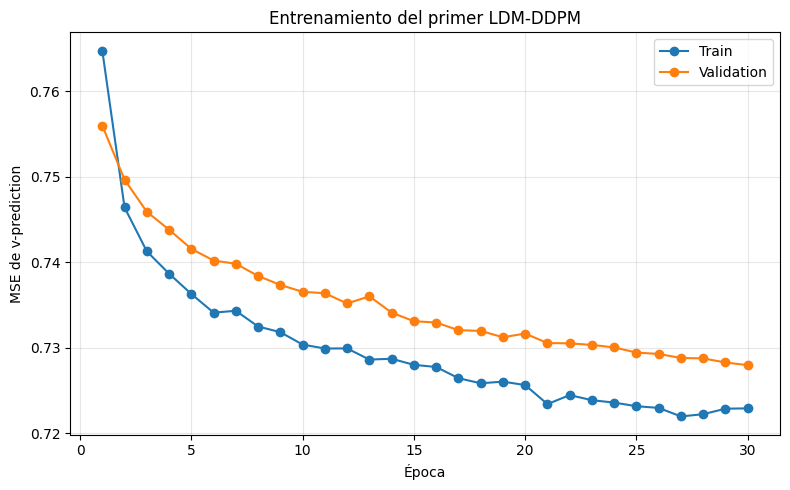

In [79]:
epochs = np.arange(1, len(ldm_history_first['train']) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, ldm_history_first['train'], marker='o', label='Train')
plt.plot(epochs, ldm_history_first['val'], marker='o', label='Validation')
plt.xlabel('Época')
plt.ylabel('MSE de v-prediction')
plt.title('Entrenamiento del primer LDM-DDPM')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [80]:
@torch.no_grad()
def latent_ddpm_reverse_step_v(model, scheduler, z_t, timestep, class_labels, noise=None):
    batch_size = z_t.shape[0]
    t_batch = torch.full((batch_size,), timestep, device=z_t.device, dtype=torch.long)
    v_prediction = model(z_t, t_batch, class_labels)
    sqrt_alpha_bar_t = scheduler.sqrt_alpha_cum_prod[timestep]
    sqrt_one_minus_alpha_bar_t = scheduler.sqrt_one_minus_alpha_cum_prod[timestep]
    z0_prediction = sqrt_alpha_bar_t * z_t - sqrt_one_minus_alpha_bar_t * v_prediction
    if timestep == 0:
        return (z0_prediction, z0_prediction)
    posterior_mean = scheduler.posterior_mean_coef1[timestep] * z0_prediction + scheduler.posterior_mean_coef2[timestep] * z_t
    posterior_variance = scheduler.posterior_variance[timestep].clamp_min(1e-20)
    if noise is None:
        noise = torch.randn_like(z_t)
    z_previous = posterior_mean + torch.sqrt(posterior_variance) * noise
    return (z_previous, z0_prediction)

In [81]:
from tqdm.auto import tqdm

@torch.no_grad()
def generate_standardized_latents_ddpm(model, scheduler, num_samples, class_labels, latent_shape=(4, 16, 16), device=device, seed=42):
    model.eval()
    if isinstance(class_labels, int):
        class_labels = torch.full((num_samples,), class_labels, dtype=torch.long, device=device)
    else:
        class_labels = torch.as_tensor(class_labels, dtype=torch.long).reshape(-1).to(device)
    if class_labels.shape[0] != num_samples:
        raise ValueError('class_labels debe tener una etiqueta por cada muestra.')
    if class_labels.min().item() < 0 or class_labels.max().item() >= NUM_CLASSES:
        raise ValueError(f'Las etiquetas deben estar entre 0 y {NUM_CLASSES - 1}.')
    if seed is not None:
        torch.manual_seed(seed)
    z_t = torch.randn((num_samples, *latent_shape), device=device)
    for timestep in tqdm(reversed(range(scheduler.num_timesteps)), total=scheduler.num_timesteps, desc='Generando latentes DDPM'):
        z_t, _ = latent_ddpm_reverse_step_v(model=model, scheduler=scheduler, z_t=z_t, timestep=timestep, class_labels=class_labels)
        if timestep % 100 == 0:
            if not torch.isfinite(z_t).all():
                raise RuntimeError(f'Aparecieron NaN o infinitos durante el timestep {timestep}.')
    if not torch.isfinite(z_t).all():
        raise RuntimeError('Los latentes finales contienen NaN o infinitos.')
    return z_t

In [82]:
NUM_GENERATED_SAMPLES = 16
generated_sample_labels = torch.tensor([0] * 8 + [1] * 8, dtype=torch.long)
generated_latents_standardized = generate_standardized_latents_ddpm(
    model=ldm_model_first, scheduler=ldm_scheduler, num_samples=NUM_GENERATED_SAMPLES,
    class_labels=generated_sample_labels, latent_shape=(4, 16, 16), device=device, seed=SEED,
)
print('Shape:', generated_latents_standardized.shape)
print('Labels:', generated_sample_labels.tolist())
print('Valores finitos:', torch.isfinite(generated_latents_standardized).all().item())

Generando latentes DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

Shape: torch.Size([16, 4, 16, 16])
Labels: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]
Valores finitos: True


In [83]:
def print_generated_latent_statistics(latents):
    latents_cpu = latents.detach().float().cpu()
    print('Media por canal:', latents_cpu.mean(dim=(0, 2, 3)).numpy())
    print('Std por canal:', latents_cpu.std(dim=(0, 2, 3), unbiased=False).numpy())
    print('Media global:', latents_cpu.mean().item())
    print('Std global:', latents_cpu.std(unbiased=False).item())
    print('Mínimo:', latents_cpu.min().item())
    print('Máximo:', latents_cpu.max().item())
    print('Fracción |z| > 4:', (latents_cpu.abs() > 4.0).float().mean().item())
    print('Fracción |z| > 6:', (latents_cpu.abs() > 6.0).float().mean().item())

In [84]:
print_generated_latent_statistics(generated_latents_standardized)

Media por canal: [-0.00665027 -0.03530974 -0.01000024 -0.0300616 ]
Std por canal: [0.9871029 0.9509741 0.9651715 1.0045309]
Media global: -0.020505458116531372
Std global: 0.9772378206253052
Mínimo: -14.253437995910645
Máximo: 13.535722732543945
Fracción |z| > 4: 0.006591796875
Fracción |z| > 6: 0.00262451171875


In [85]:
latent_mean_device = latent_mean_train.to(device).float()
latent_std_device = latent_std_train.to(device).float()
generated_latents_original = generated_latents_standardized * latent_std_device + latent_mean_device
print('Latentes desestandarizados:', generated_latents_original.shape)
print('Valores finitos:', torch.isfinite(generated_latents_original).all().item())

Latentes desestandarizados: torch.Size([16, 4, 16, 16])
Valores finitos: True


In [86]:
@torch.no_grad()
def decode_generated_latents(vae_model, latent_tensor):
    vae_model.eval()
    generated_images_m11 = vae_model.decode_hard(latent_tensor)
    generated_images_01 = ((generated_images_m11 + 1.0) / 2.0).clamp(0.0, 1.0)
    return generated_images_01

In [87]:
generated_jets_01 = decode_generated_latents(vae_model=vae_model, latent_tensor=generated_latents_original)
print('Jets generados:', generated_jets_01.shape)
print('Mínimo:', generated_jets_01.min().item())
print('Máximo:', generated_jets_01.max().item())
print('Valores finitos:', torch.isfinite(generated_jets_01).all().item())

Jets generados: torch.Size([16, 3, 64, 64])
Mínimo: 0.0
Máximo: 1.0
Valores finitos: True


In [88]:
def plot_generated_jets(generated_images_01, num_images=8, contrast=True):
    images = generated_images_01.detach().float().cpu()
    num_images = min(num_images, images.shape[0])
    num_columns = 4
    num_rows = int(np.ceil(num_images / num_columns))
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(3.4 * num_columns, 3.4 * num_rows))
    axes = np.asarray(axes).reshape(-1)
    for index in range(num_images):
        image = images[index]
        total_intensity = image.sum().item()
        maximum = image.max().item()
        active_fraction = (image > 0.0001).float().mean().item()
        image_to_show = image.permute(1, 2, 0).numpy()
        if contrast:
            display_maximum = image_to_show.max()
            if display_maximum > 0:
                image_to_show = image_to_show / display_maximum
        axes[index].imshow(image_to_show)
        axes[index].set_title(f'Jet {index + 1}\nI={total_intensity:.2f}, max={maximum:.3f}\nact={100 * active_fraction:.2f}%')
        axes[index].axis('off')
    for index in range(num_images, len(axes)):
        axes[index].axis('off')
    fig.tight_layout()
    plt.show()

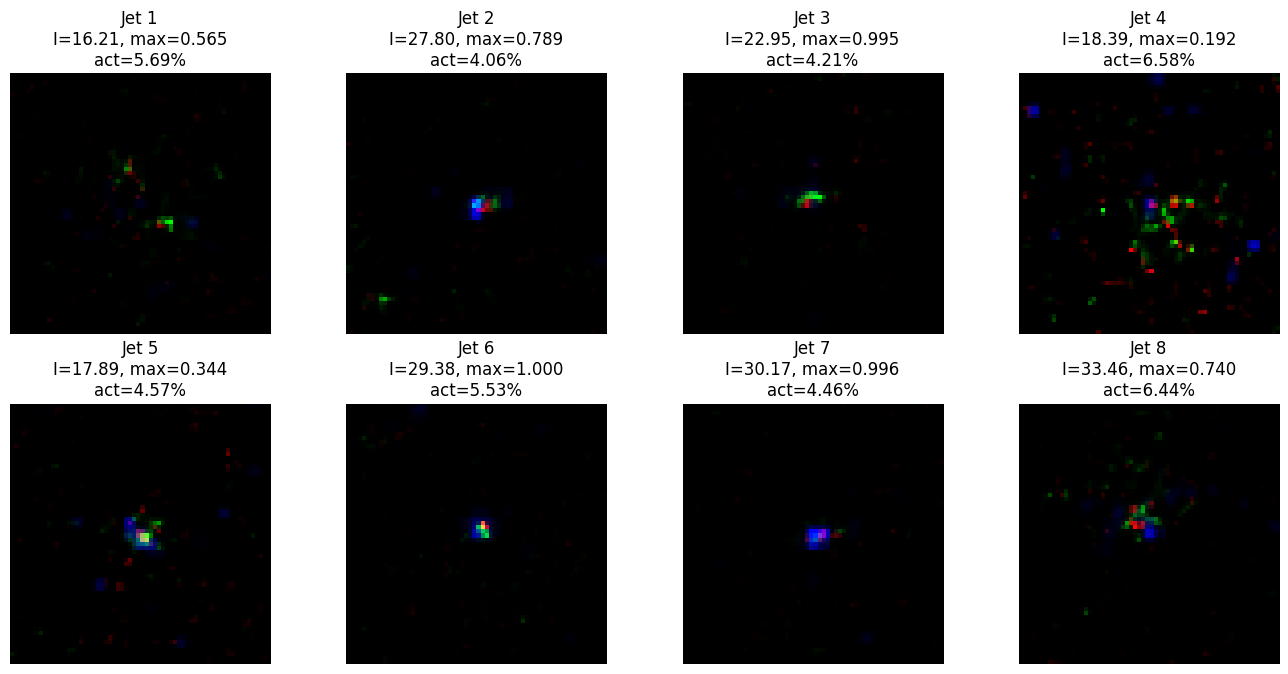

In [89]:
plot_generated_jets(generated_jets_01, num_images=8, contrast=True)

CLASE 0


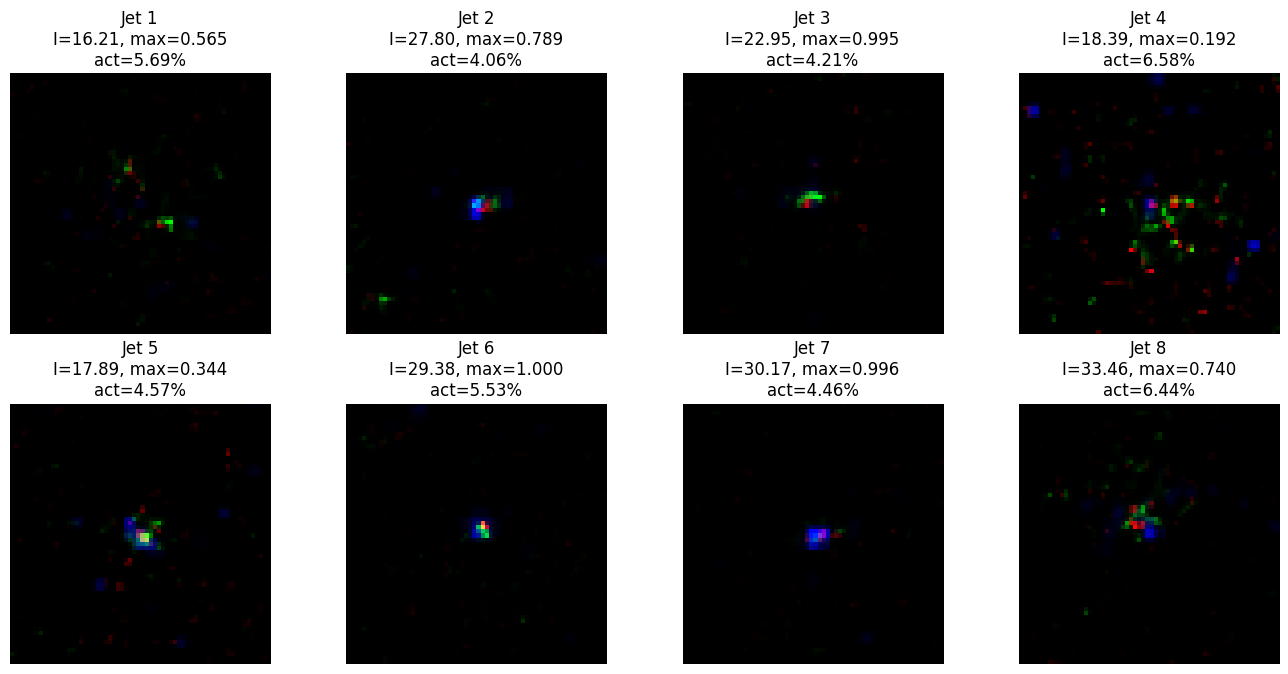

CLASE 1


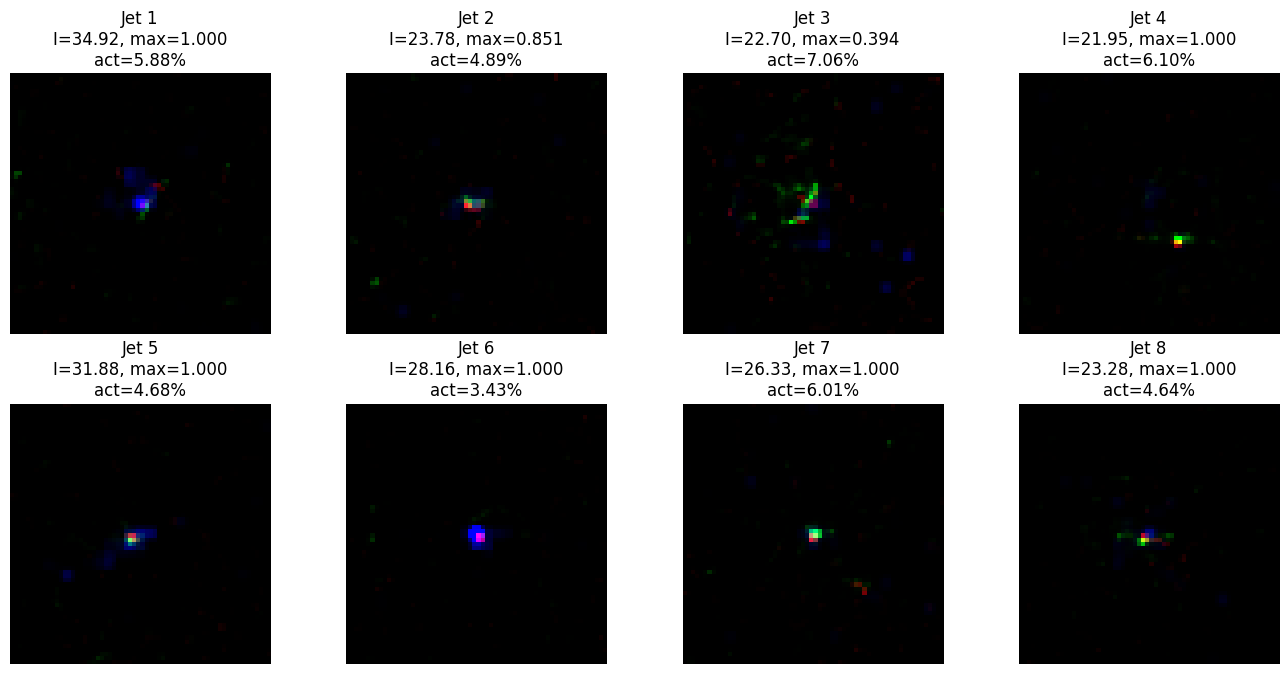

In [90]:
print('========================================')
print('CLASE 0')
print('========================================')
plot_generated_jets(generated_jets_01[:8], num_images=8, contrast=True)
print('========================================')
print('CLASE 1')
print('========================================')
plot_generated_jets(generated_jets_01[8:16], num_images=8, contrast=True)

In [91]:
@torch.no_grad()
def generate_jet_dataset_ddpm(
    ldm_model, scheduler, vae_model, latent_mean, latent_std, num_samples, class_labels, batch_size=64,
    latent_shape=(4, 16, 16), device=device, seed=42,
):
    ldm_model.eval()
    vae_model.eval()
    class_labels = torch.as_tensor(class_labels, dtype=torch.long).reshape(-1)
    if class_labels.shape[0] != num_samples:
        raise ValueError(f'class_labels debe contener exactamente {num_samples} etiquetas.')
    if class_labels.min().item() < 0 or class_labels.max().item() >= NUM_CLASSES:
        raise ValueError(f'Las etiquetas deben estar entre 0 y {NUM_CLASSES - 1}.')
    if seed is not None:
        torch.manual_seed(seed)
    latent_mean = latent_mean.to(device).float()
    latent_std = latent_std.to(device).float()
    generated_batches = []
    generated_latent_batches = []
    num_batches = int(np.ceil(num_samples / batch_size))
    for batch_index in tqdm(range(num_batches), desc='Generando dataset con LDM'):
        current_batch_size = min(batch_size, num_samples - batch_index * batch_size)
        start_index = batch_index * batch_size
        end_index = start_index + current_batch_size
        batch_labels = class_labels[start_index:end_index].to(device)
        z_t = torch.randn((current_batch_size, *latent_shape), device=device)
        for timestep in reversed(range(scheduler.num_timesteps)):
            z_t, _ = latent_ddpm_reverse_step_v(model=ldm_model, scheduler=scheduler, z_t=z_t, timestep=timestep, class_labels=batch_labels)
        generated_latent_batches.append(z_t.detach().cpu())
        z_original = z_t * latent_std + latent_mean
        generated_m11 = vae_model.decode_hard(z_original)
        generated_01 = ((generated_m11 + 1.0) / 2.0).clamp(0.0, 1.0)
        generated_batches.append(generated_01.detach().cpu())
    generated_images_01 = torch.cat(generated_batches, dim=0)
    generated_latents_standardized = torch.cat(generated_latent_batches, dim=0)
    return (generated_images_01, generated_latents_standardized, class_labels.cpu())

In [92]:
NUM_GENERATED_JETS = 2500
generation_labels_2500 = ldm_test_labels[:NUM_GENERATED_JETS].clone()
print('Distribución de clases a generar:', torch.unique(generation_labels_2500, return_counts=True))
generated_images_01, generated_latents_2500, generated_labels_2500 = generate_jet_dataset_ddpm(
    ldm_model=ldm_model_first, scheduler=ldm_scheduler, vae_model=vae_model, latent_mean=latent_mean_train,
    latent_std=latent_std_train, num_samples=NUM_GENERATED_JETS, class_labels=generation_labels_2500,
    batch_size=64, latent_shape=(4, 16, 16), device=device, seed=SEED,
)
print('Shape:', generated_images_01.shape)
print('Min:', generated_images_01.min().item())
print('Max:', generated_images_01.max().item())
print('Finitos:', torch.isfinite(generated_images_01).all().item())
print('Shape latentes generados:', generated_latents_2500.shape)
print('Latentes finitos:', torch.isfinite(generated_latents_2500).all().item())

Distribución de clases a generar: (tensor([0, 1]), tensor([1240, 1260]))


Generando dataset con LDM:   0%|          | 0/40 [00:00<?, ?it/s]

Shape: torch.Size([2500, 3, 64, 64])
Min: 0.0
Max: 1.0
Finitos: True
Shape latentes generados: torch.Size([2500, 4, 16, 16])
Latentes finitos: True


In [93]:
print_generated_latent_statistics(generated_latents_2500)

Media por canal: [-0.02802141 -0.02157409 -0.00149819 -0.03073228]
Std por canal: [1.0347441  1.0071731  0.98914105 1.0204494 ]
Media global: -0.020456481724977493
Std global: 1.0130810737609863
Mínimo: -22.980981826782227
Máximo: 19.14982795715332
Fracción |z| > 4: 0.008016015402972698
Fracción |z| > 6: 0.0029519530944526196


In [94]:
@torch.no_grad()
def collect_real_images_from_loader(data_loader, device=device):
    image_batches = []
    for images, _ in data_loader:
        images = images.to(device)
        images_01 = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
        image_batches.append(images_01.detach().cpu())
    return torch.cat(image_batches, dim=0)

In [95]:
real_test_images_01 = collect_real_images_from_loader(test_loader, device=device)
print('Shape real:', real_test_images_01.shape)
print('Min real:', real_test_images_01.min().item())
print('Max real:', real_test_images_01.max().item())

Shape real: torch.Size([13932, 3, 64, 64])
Min real: 0.0
Max real: 1.0


In [96]:
from scipy.stats import wasserstein_distance
CHANNEL_NAMES = ['TRACKER', 'ECAL', 'HCAL']

@torch.no_grad()
def collect_image_diagnostics(images_01, active_thr_01=0.0001, num_radial_bins=32):
    images_01 = images_01.float().cpu()
    batch_size, channels, height, width = images_01.shape
    energy = images_01.sum(dim=(-2, -1)).numpy()
    active_fraction = (images_01 > active_thr_01).float().mean(dim=(-2, -1)).numpy()
    maximum = images_01.amax(dim=(-2, -1)).numpy()
    y_coordinates, x_coordinates = torch.meshgrid(torch.arange(height, dtype=torch.float32), torch.arange(width, dtype=torch.float32), indexing='ij')
    center_y = (height - 1) / 2.0
    center_x = (width - 1) / 2.0
    radius = torch.sqrt((y_coordinates - center_y) ** 2 + (x_coordinates - center_x) ** 2)
    radial_edges = torch.linspace(0.0, radius.max().item() + 1e-06, num_radial_bins + 1)
    radial_centers = (0.5 * (radial_edges[:-1] + radial_edges[1:])).numpy()
    radial_bin_index = (torch.bucketize(radius.reshape(-1), radial_edges, right=False) - 1).clamp(min=0, max=num_radial_bins - 1)
    radial_sum = torch.zeros(channels, num_radial_bins, dtype=torch.float64)
    flat_images = images_01.reshape(batch_size, channels, -1).double()
    for radial_bin in range(num_radial_bins):
        radial_mask = radial_bin_index == radial_bin
        radial_sum[:, radial_bin] += flat_images[:, :, radial_mask].sum(dim=(0, 2))
    radial_profile = (radial_sum / radial_sum.sum(dim=1, keepdim=True).clamp_min(1e-12)).numpy()
    return {
        'images': images_01,
        'energy': energy,
        'active_fraction': active_fraction,
        'maximum': maximum,
        'radial_centers': radial_centers,
        'radial_profile': radial_profile,
    }

In [97]:
real_diag = collect_image_diagnostics(real_test_images_01, active_thr_01=0.0001, num_radial_bins=32)
gen_diag = collect_image_diagnostics(generated_images_01, active_thr_01=0.0001, num_radial_bins=32)

In [98]:
def summarize_real_vs_generated(real_diag, gen_diag):
    rows = []
    for channel, channel_name in enumerate(CHANNEL_NAMES):
        e_real = real_diag['energy'][:, channel]
        e_gen = gen_diag['energy'][:, channel]
        a_real = real_diag['active_fraction'][:, channel]
        a_gen = gen_diag['active_fraction'][:, channel]
        m_real = real_diag['maximum'][:, channel]
        m_gen = gen_diag['maximum'][:, channel]
        radial_real = real_diag['radial_profile'][channel]
        radial_gen = gen_diag['radial_profile'][channel]
        row = {
            'Canal': channel_name,
            'E real media': e_real.mean(),
            'E gen media': e_gen.mean(),
            'Bias E (%)': 100.0 * (e_gen.mean() - e_real.mean()) / max(e_real.mean(), 1e-12),
            'W1 energía': wasserstein_distance(e_real, e_gen),
            'Fracción activa real': a_real.mean(),
            'Fracción activa gen': a_gen.mean(),
            'Diferencia activa (p.p.)': 100.0 * (a_gen.mean() - a_real.mean()),
            'Máximo real medio': m_real.mean(),
            'Máximo gen medio': m_gen.mean(),
            'W1 máximo': wasserstein_distance(m_real, m_gen),
            'Radial L1': np.mean(np.abs(radial_gen - radial_real)),
            'Radial L2': np.sqrt(np.mean((radial_gen - radial_real) ** 2)),
        }
        rows.append(row)
    return pd.DataFrame(rows)

In [99]:
summary_ldm = summarize_real_vs_generated(real_diag, gen_diag)
display(summary_ldm.round(6))

,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,TRACKER,5.903112,6.678690,13.138459,0.806576,0.041582,0.044881,0.329916,0.761202,0.691925,0.069394,0.002383,0.004695
1,ECAL,7.761820,8.000010,3.068735,0.328590,0.053231,0.053192,-0.003907,0.827062,0.736486,0.090616,0.000820,0.001072
2,HCAL,11.560102,12.708732,9.936151,1.148630,0.044967,0.060192,1.522433,0.528693,0.553034,0.028854,0.001305,0.002313


In [100]:
def print_global_generation_summary(real_diag, gen_diag):
    total_real = real_diag['energy'].sum(axis=1)
    total_gen = gen_diag['energy'].sum(axis=1)
    active_real = real_diag['active_fraction'].mean(axis=1)
    active_gen = gen_diag['active_fraction'].mean(axis=1)
    max_real = real_diag['maximum'].max(axis=1)
    max_gen = gen_diag['maximum'].max(axis=1)
    print('============================================================')
    print('RESUMEN GLOBAL: REAL vs GENERADO')
    print('============================================================')
    print(f'Intensidad total media real      : {total_real.mean():.6f}')
    print(f'Intensidad total media generada  : {total_gen.mean():.6f}')
    print(f'Bias total (%)                   : {100 * (total_gen.mean() - total_real.mean()) / max(total_real.mean(), 1e-12):.6f}')
    print(f'W1 intensidad total              : {wasserstein_distance(total_real, total_gen):.6f}')
    print()
    print(f'Fracción activa media real       : {active_real.mean():.6f}')
    print(f'Fracción activa media generada   : {active_gen.mean():.6f}')
    print(f'Diferencia activa (p.p.)         : {100 * (active_gen.mean() - active_real.mean()):.6f}')
    print()
    print(f'Máximo global medio real         : {max_real.mean():.6f}')
    print(f'Máximo global medio generado     : {max_gen.mean():.6f}')
    print(f'W1 máximo global                 : {wasserstein_distance(max_real, max_gen):.6f}')

In [101]:
print_global_generation_summary(real_diag, gen_diag)

RESUMEN GLOBAL: REAL vs GENERADO
Intensidad total media real      : 25.225033
Intensidad total media generada  : 27.387432
Bias total (%)                   : 8.572434
W1 intensidad total              : 2.217455

Fracción activa media real       : 0.046593
Fracción activa media generada   : 0.052755
Diferencia activa (p.p.)         : 0.616147

Máximo global medio real         : 0.936509
Máximo global medio generado     : 0.882881
W1 máximo global                 : 0.053628


In [102]:
def summarize_generation_by_class(real_images, real_labels, generated_images, generated_labels):
    real_labels = torch.as_tensor(real_labels).long().cpu().reshape(-1)
    generated_labels = torch.as_tensor(generated_labels).long().cpu().reshape(-1)
    tables = []
    class_ids = sorted(set(real_labels.tolist()) & set(generated_labels.tolist()))
    for class_id in class_ids:
        real_mask = real_labels == class_id
        generated_mask = generated_labels == class_id
        real_class_images = real_images[real_mask]
        generated_class_images = generated_images[generated_mask]
        print(f'Clase {class_id}: {real_mask.sum().item()} reales | {generated_mask.sum().item()} generados')
        real_class_diag = collect_image_diagnostics(real_class_images, active_thr_01=0.0001, num_radial_bins=32)
        generated_class_diag = collect_image_diagnostics(generated_class_images, active_thr_01=0.0001, num_radial_bins=32)
        class_summary = summarize_real_vs_generated(real_class_diag, generated_class_diag)
        class_summary.insert(0, 'Clase', class_id)
        class_summary.insert(1, 'N real', real_mask.sum().item())
        class_summary.insert(2, 'N generado', generated_mask.sum().item())
        tables.append(class_summary)
    return pd.concat(tables, ignore_index=True)

In [103]:
summary_by_class = summarize_generation_by_class(
    real_images=real_test_images_01, real_labels=ldm_test_labels, generated_images=generated_images_01,
    generated_labels=generated_labels_2500,
)
display(summary_by_class.round(6))

Clase 0: 6923 reales | 1240 generados
Clase 1: 7009 reales | 1260 generados


,Clase,N real,N generado,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,0,6923,1240,TRACKER,6.225820,7.112140,14.236216,0.938247,0.043777,0.047189,0.341189,0.708338,0.638244,0.070179,0.002354,0.004204
1,0,6923,1240,ECAL,7.998604,8.225818,2.840675,0.372558,0.057934,0.056959,-0.097479,0.783885,0.686758,0.097141,0.000937,0.001278
2,0,6923,1240,HCAL,11.283746,12.320776,9.190478,1.037182,0.047246,0.064271,1.702496,0.487645,0.502393,0.023885,0.001463,0.002648
3,1,7009,1260,TRACKER,5.584366,6.252119,11.957548,0.697459,0.039413,0.042609,0.319612,0.813416,0.744754,0.068848,0.002753,0.005436
4,1,7009,1260,ECAL,7.527940,7.777784,3.318897,0.317993,0.048586,0.049485,0.089873,0.869708,0.785424,0.084361,0.001605,0.002338
5,1,7009,1260,HCAL,11.833066,13.090528,10.626683,1.269892,0.042717,0.056177,1.346050,0.569238,0.602870,0.035937,0.001244,0.002119


In [104]:
@torch.no_grad()
def test_class_conditioning_effect(model, data_loader, scheduler, device, timestep_values=(100, 300, 500, 700, 900), num_samples=64):
    model.eval()
    z0, _ = next(iter(data_loader))
    z0 = z0[:num_samples].float().to(device)
    results = []
    for timestep in timestep_values:
        t_batch = torch.full((z0.shape[0],), timestep, dtype=torch.long, device=device)
        noise = torch.randn_like(z0)
        z_t, _ = scheduler.add_noise(z0, t_batch, noise)
        labels_0 = torch.zeros(z0.shape[0], dtype=torch.long, device=device)
        labels_1 = torch.ones(z0.shape[0], dtype=torch.long, device=device)
        prediction_0 = model(z_t, t_batch, labels_0)
        prediction_1 = model(z_t, t_batch, labels_1)
        absolute_difference = (prediction_0 - prediction_1).abs().mean().item()
        prediction_scale = (0.5 * (prediction_0.abs().mean() + prediction_1.abs().mean())).item()
        relative_difference = absolute_difference / max(prediction_scale, 1e-12)
        results.append({'timestep': timestep, 'mean_abs_difference': absolute_difference, 'relative_difference': relative_difference})
    return pd.DataFrame(results)
conditioning_effect = test_class_conditioning_effect(model=ldm_model_first, data_loader=ldm_test_loader, scheduler=ldm_scheduler, device=device)
display(conditioning_effect)

,timestep,mean_abs_difference,relative_difference
0,100,0.009366,0.019883
1,300,0.013371,0.030773
2,500,0.032566,0.104486
3,700,0.048563,0.197011
4,900,0.047091,0.198017


In [105]:
@torch.no_grad()
def generate_paired_classes_ddpm(model, scheduler, num_samples=256, latent_shape=(4, 16, 16), class_a=0, class_b=1, device=device, seed=42):
    model.eval()
    generator = torch.Generator(device='cpu').manual_seed(seed)
    z_initial = torch.randn((num_samples, *latent_shape), generator=generator, dtype=torch.float32, device='cpu').to(device)
    labels_0 = torch.full((num_samples,), class_a, dtype=torch.long, device=device)
    labels_1 = torch.full((num_samples,), class_b, dtype=torch.long, device=device)
    z_class_0 = z_initial.clone()
    z_class_1 = z_initial.clone()
    for timestep in reversed(range(scheduler.num_timesteps)):
        if timestep > 0:
            shared_noise = torch.randn(z_class_0.shape, generator=generator, dtype=z_class_0.dtype, device='cpu').to(device)
        else:
            shared_noise = None
        z_class_0, _ = latent_ddpm_reverse_step_v(model=model, scheduler=scheduler, z_t=z_class_0, timestep=timestep, class_labels=labels_0, noise=shared_noise)
        z_class_1, _ = latent_ddpm_reverse_step_v(model=model, scheduler=scheduler, z_t=z_class_1, timestep=timestep, class_labels=labels_1, noise=shared_noise)
    return (z_class_0, z_class_1)

In [106]:
paired_latents_0, paired_latents_1 = generate_paired_classes_ddpm(
    model=ldm_model_first, scheduler=ldm_scheduler, num_samples=256, latent_shape=(4, 16, 16), device=device,
    seed=SEED,
)
print('Diferencia absoluta media:', (paired_latents_0 - paired_latents_1).abs().mean().item())
print('MSE entre clases:', F.mse_loss(paired_latents_0, paired_latents_1).item())

Diferencia absoluta media: 0.12722647190093994
MSE entre clases: 0.07168231904506683


In [107]:
control_latents_a, control_latents_b = generate_paired_classes_ddpm(
    model=ldm_model_first, scheduler=ldm_scheduler, num_samples=256, latent_shape=(4, 16, 16), class_a=0,
    class_b=0, device=device, seed=SEED,
)
print('CONTROL: class 0 vs class 0')
print('Diferencia absoluta media:', (control_latents_a - control_latents_b).abs().mean().item())
print('MSE:', F.mse_loss(control_latents_a, control_latents_b).item())

CONTROL: class 0 vs class 0
Diferencia absoluta media: 0.0
MSE: 0.0


In [108]:
paired_latents_0, paired_latents_1 = generate_paired_classes_ddpm(
    model=ldm_model_first, scheduler=ldm_scheduler, num_samples=256, latent_shape=(4, 16, 16), class_a=0,
    class_b=1, device=device, seed=SEED,
)
print('CONDITIONING: class 0 vs class 1')
print('Diferencia absoluta media:', (paired_latents_0 - paired_latents_1).abs().mean().item())
print('MSE:', F.mse_loss(paired_latents_0, paired_latents_1).item())

CONDITIONING: class 0 vs class 1
Diferencia absoluta media: 0.12722647190093994
MSE: 0.07168231904506683


In [109]:
comparison_diagnostics = {
    'energy_real': real_diag['energy'],
    'energy_recon': gen_diag['energy'],
    'active_frac_real': real_diag['active_fraction'],
    'active_frac_recon': gen_diag['active_fraction'],
    'max_real': real_diag['maximum'],
    'max_recon': gen_diag['maximum'],
    'radial_centers': real_diag['radial_centers'],
    'radial_real': real_diag['radial_profile'],
    'radial_recon': gen_diag['radial_profile'],
}

In [110]:
def build_class_comparison_diagnostics(real_diag, generated_diag, real_labels, generated_labels, class_id):
    real_labels_np = torch.as_tensor(real_labels).long().cpu().numpy().reshape(-1)
    generated_labels_np = torch.as_tensor(generated_labels).long().cpu().numpy().reshape(-1)
    real_mask = real_labels_np == class_id
    generated_mask = generated_labels_np == class_id
    if real_mask.sum() == 0:
        raise ValueError(f'No hay eventos reales de clase {class_id}.')
    if generated_mask.sum() == 0:
        raise ValueError(f'No hay eventos generados de clase {class_id}.')
    class_diagnostics = {
        'energy_real': np.asarray(real_diag['energy'])[real_mask],
        'energy_recon': np.asarray(generated_diag['energy'])[generated_mask],
        'active_frac_real': np.asarray(real_diag['active_fraction'])[real_mask],
        'active_frac_recon': np.asarray(generated_diag['active_fraction'])[generated_mask],
        'max_real': np.asarray(real_diag['maximum'])[real_mask],
        'max_recon': np.asarray(generated_diag['maximum'])[generated_mask],
    }
    print(f'Clase {class_id}: {real_mask.sum()} reales | {generated_mask.sum()} generados')
    return class_diagnostics

In [111]:
comparison_diagnostics_class_0 = build_class_comparison_diagnostics(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, class_id=0,
)
comparison_diagnostics_class_1 = build_class_comparison_diagnostics(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, class_id=1,
)

Clase 0: 6923 reales | 1240 generados
Clase 1: 7009 reales | 1260 generados


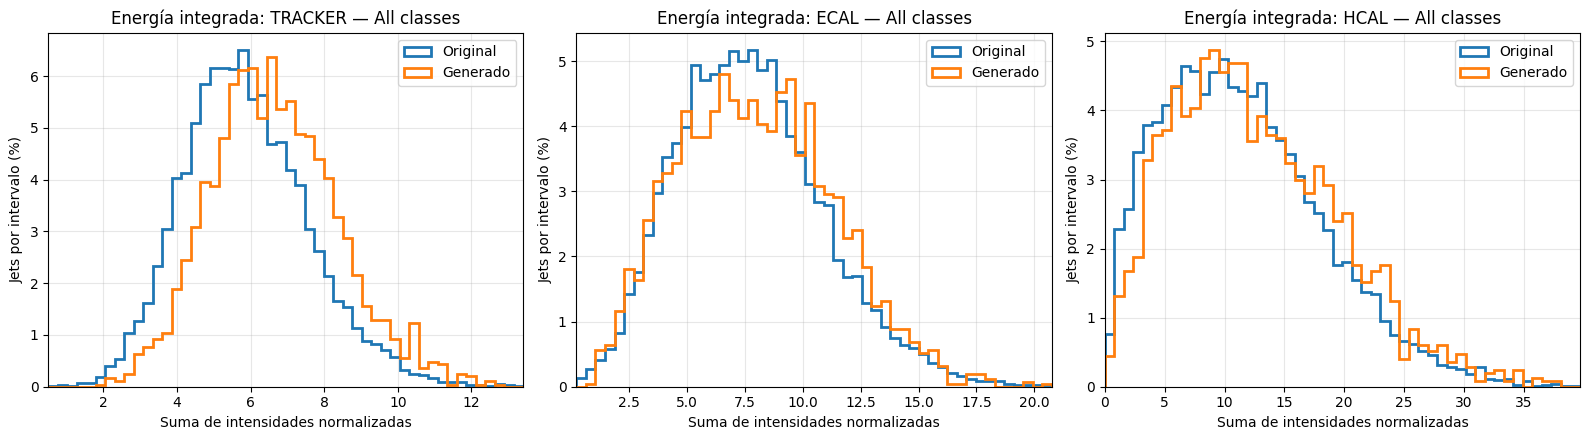

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Energía integrada: TRACKER — All classes'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: ECAL — All classes'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: HCAL — All classes'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [112]:
plot_channel_distributions(comparison_diagnostics, metric='energy', num_bins=50, upper_quantile=0.999, class_name='All classes')

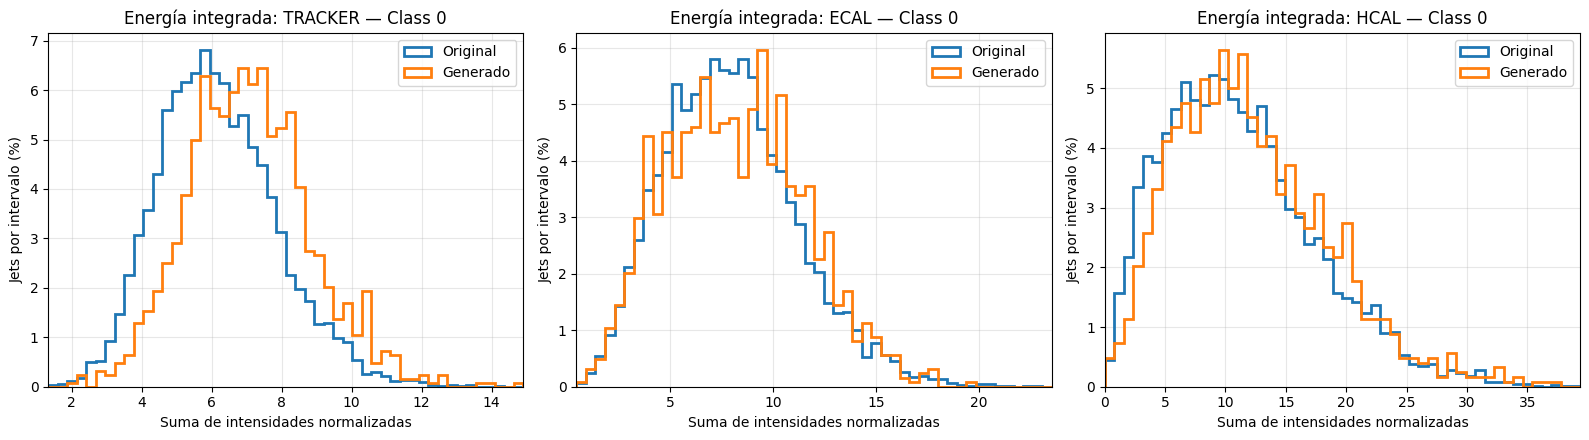

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Energía integrada: TRACKER — Class 0'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: ECAL — Class 0'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: HCAL — Class 0'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [113]:
plot_channel_distributions(comparison_diagnostics_class_0, metric='energy', num_bins=50, upper_quantile=0.999, class_name='Class 0')

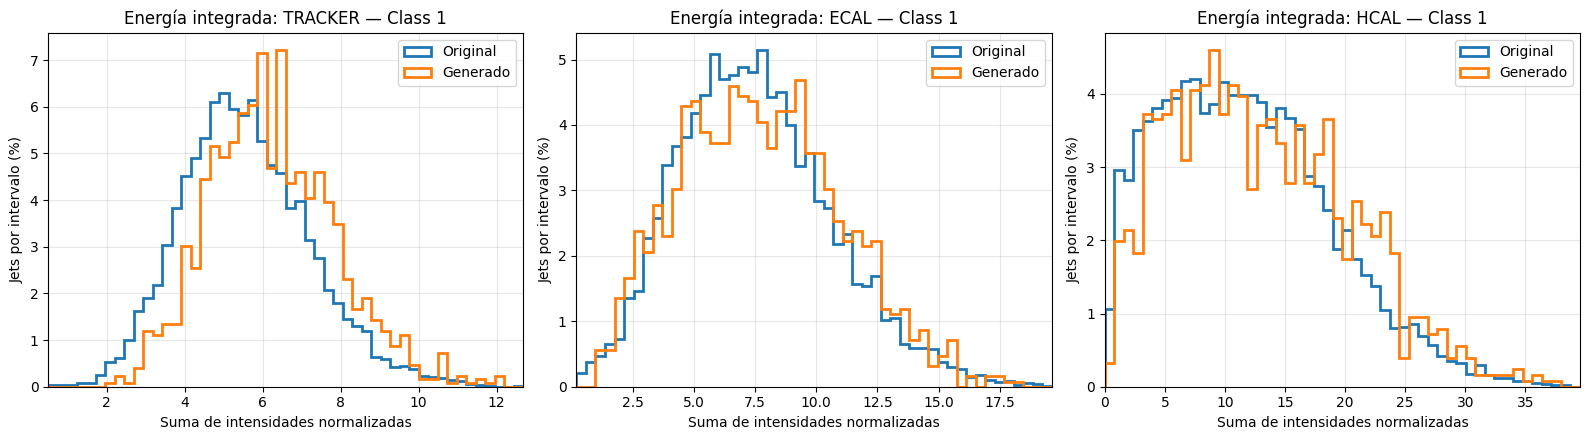

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Energía integrada: TRACKER — Class 1'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: ECAL — Class 1'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Energía integrada: HCAL — Class 1'}, xlabel='Suma de intensidades normalizadas', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [114]:
plot_channel_distributions(comparison_diagnostics_class_1, metric='energy', num_bins=50, upper_quantile=0.999, class_name='Class 1')

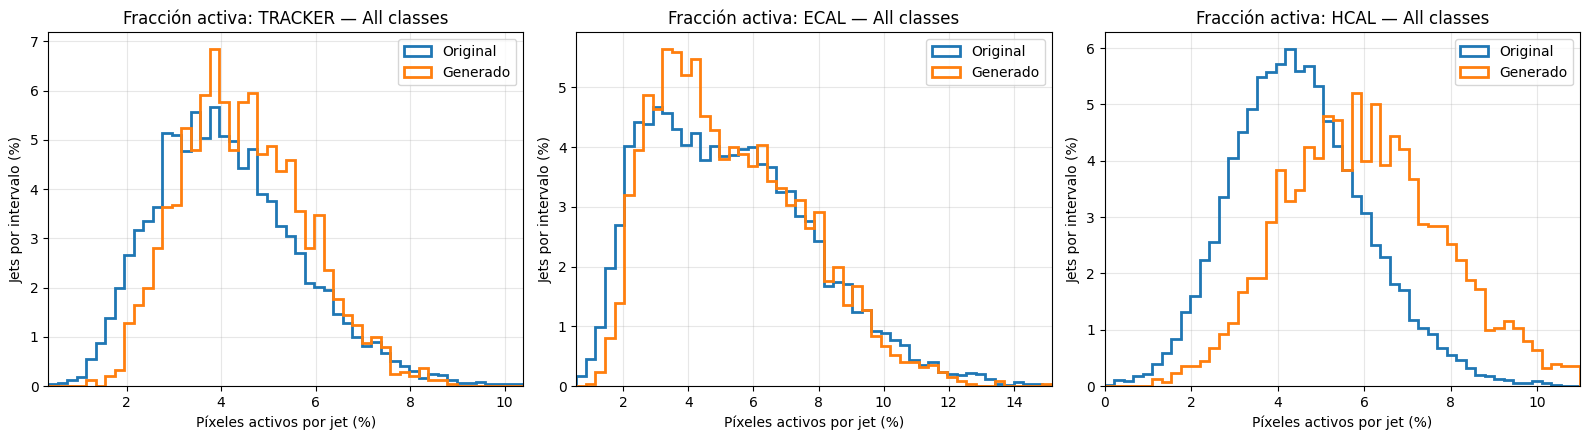

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Fracción activa: TRACKER — All classes'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: ECAL — All classes'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: HCAL — All classes'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [115]:
plot_channel_distributions(comparison_diagnostics, metric='active_fraction', num_bins=50, upper_quantile=0.999, class_name='All classes')

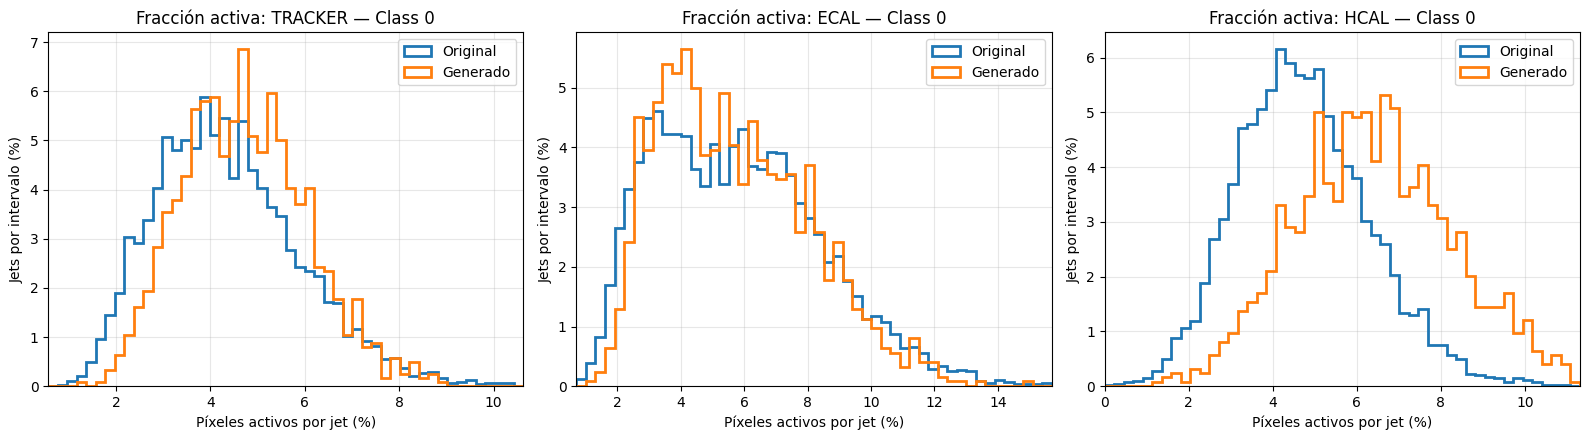

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Fracción activa: TRACKER — Class 0'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: ECAL — Class 0'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: HCAL — Class 0'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [116]:
plot_channel_distributions(comparison_diagnostics_class_0, metric='active_fraction', num_bins=50, upper_quantile=0.999, class_name='Class 0')

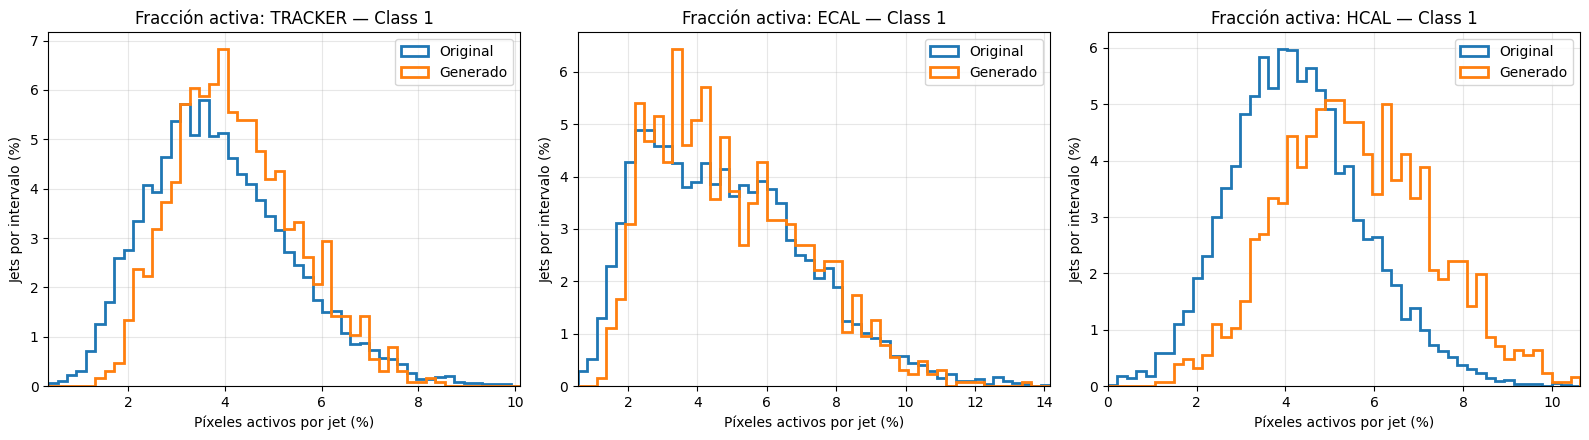

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Fracción activa: TRACKER — Class 1'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: ECAL — Class 1'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Fracción activa: HCAL — Class 1'}, xlabel='Píxeles activos por jet (%)', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [117]:
plot_channel_distributions(comparison_diagnostics_class_1, metric='active_fraction', num_bins=50, upper_quantile=0.999, class_name='Class 1')

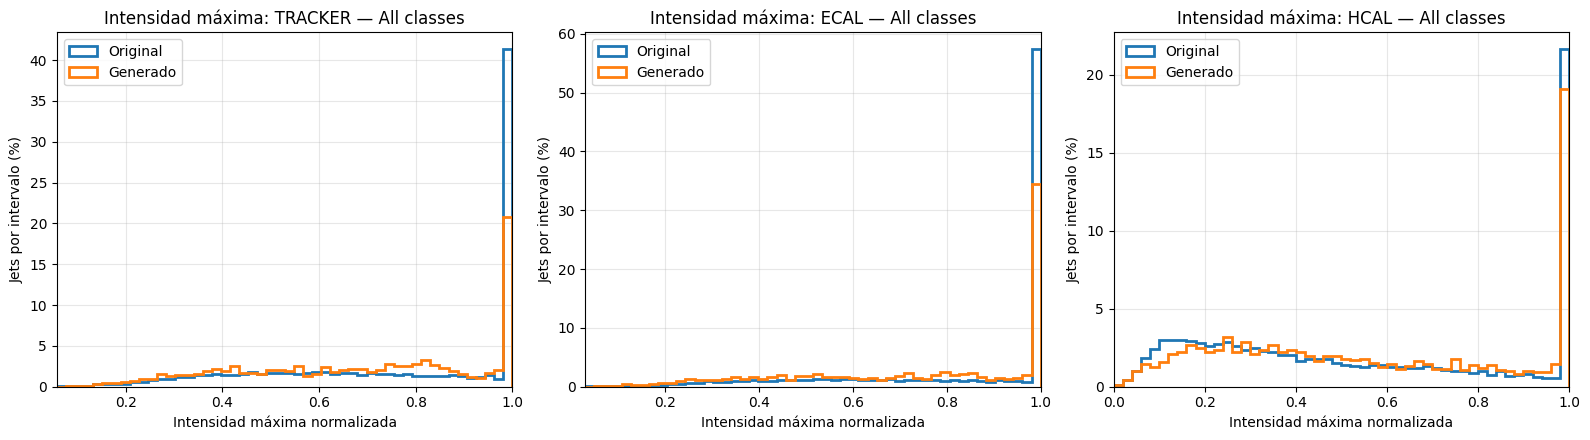

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Intensidad máxima: TRACKER — All classes'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: ECAL — All classes'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: HCAL — All classes'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [118]:
plot_channel_distributions(comparison_diagnostics, metric='maximum', num_bins=50, upper_quantile=0.999, class_name='All classes')

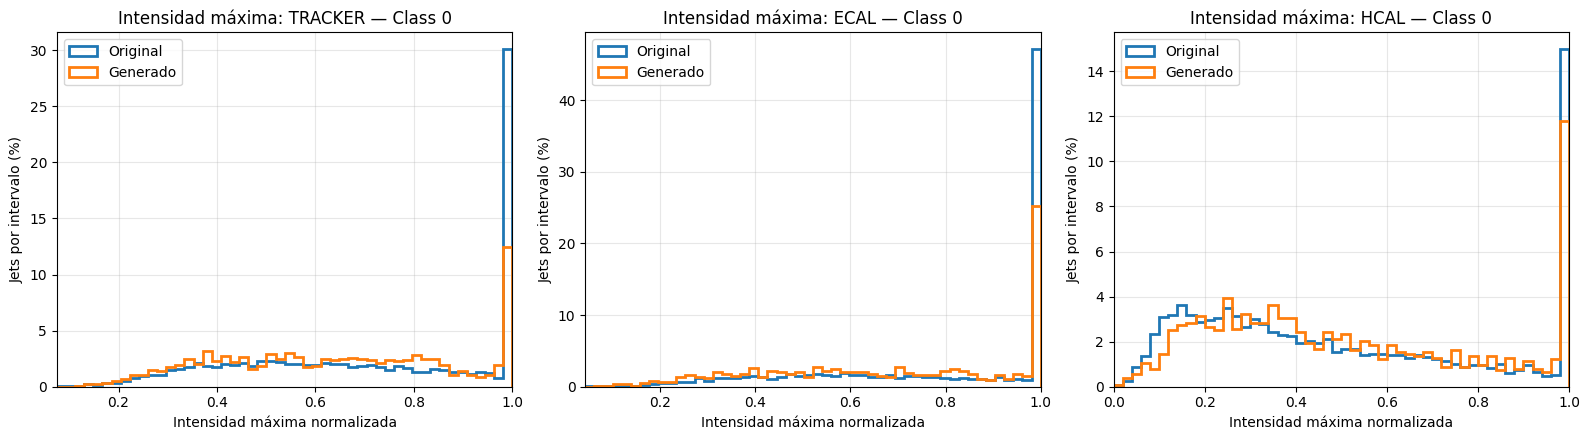

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Intensidad máxima: TRACKER — Class 0'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: ECAL — Class 0'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: HCAL — Class 0'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [119]:
plot_channel_distributions(comparison_diagnostics_class_0, metric='maximum', num_bins=50, upper_quantile=0.999, class_name='Class 0')

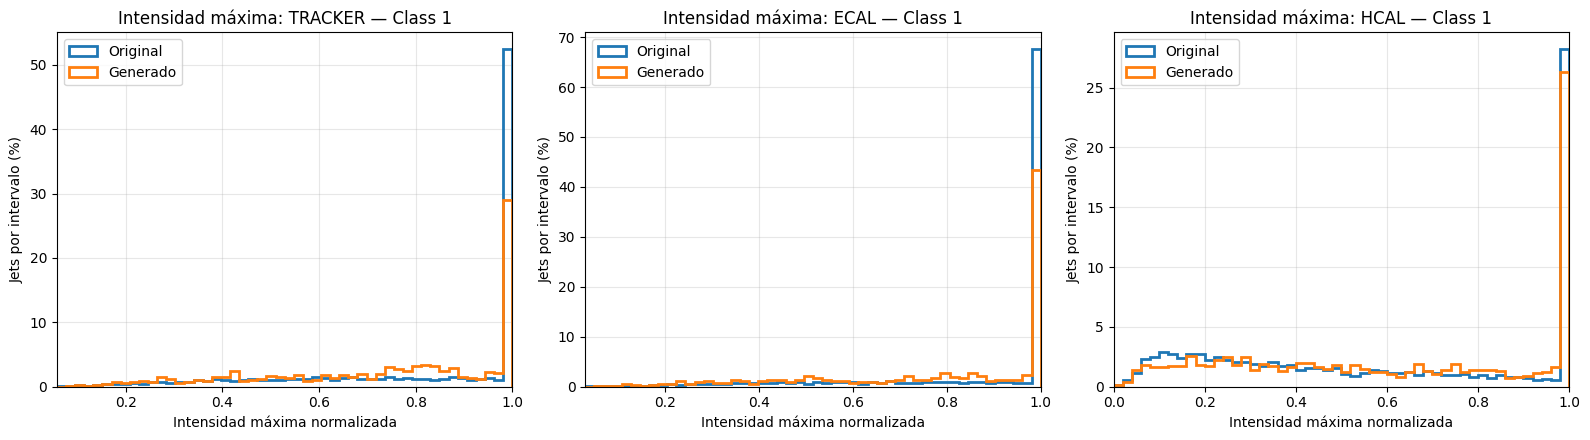

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Intensidad máxima: TRACKER — Class 1'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: ECAL — Class 1'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>,
        <Axes: title={'center': 'Intensidad máxima: HCAL — Class 1'}, xlabel='Intensidad máxima normalizada', ylabel='Jets por intervalo (%)'>],
       dtype=object))

In [120]:
plot_channel_distributions(comparison_diagnostics_class_1, metric='maximum', num_bins=50, upper_quantile=0.999, class_name='Class 1')

In [121]:
summary_by_class = summarize_generation_by_class(
    real_images=real_test_images_01, real_labels=ldm_test_labels, generated_images=generated_images_01,
    generated_labels=generated_labels_2500,
)
display(summary_by_class.round(6))

Clase 0: 6923 reales | 1240 generados
Clase 1: 7009 reales | 1260 generados


,Clase,N real,N generado,Canal,E real media,E gen media,Bias E (%),W1 energía,Fracción activa real,Fracción activa gen,Diferencia activa (p.p.),Máximo real medio,Máximo gen medio,W1 máximo,Radial L1,Radial L2
0,0,6923,1240,TRACKER,6.225820,7.112140,14.236216,0.938247,0.043777,0.047189,0.341189,0.708338,0.638244,0.070179,0.002354,0.004204
1,0,6923,1240,ECAL,7.998604,8.225818,2.840675,0.372558,0.057934,0.056959,-0.097479,0.783885,0.686758,0.097141,0.000937,0.001278
2,0,6923,1240,HCAL,11.283746,12.320776,9.190478,1.037182,0.047246,0.064271,1.702496,0.487645,0.502393,0.023885,0.001463,0.002648
3,1,7009,1260,TRACKER,5.584366,6.252119,11.957548,0.697459,0.039413,0.042609,0.319612,0.813416,0.744754,0.068848,0.002753,0.005436
4,1,7009,1260,ECAL,7.527940,7.777784,3.318897,0.317993,0.048586,0.049485,0.089873,0.869708,0.785424,0.084361,0.001605,0.002338
5,1,7009,1260,HCAL,11.833066,13.090528,10.626683,1.269892,0.042717,0.056177,1.346050,0.569238,0.602870,0.035937,0.001244,0.002119


In [122]:
def plot_radial_profiles_from_diagnostics(comparison_diagnostics):
    radial_centers = comparison_diagnostics['radial_centers']
    radial_real = comparison_diagnostics['radial_real']
    radial_gen = comparison_diagnostics['radial_recon']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for channel, channel_name in enumerate(CHANNEL_NAMES):
        axes[channel].plot(radial_centers, radial_real[channel], marker='o', label='Real')
        axes[channel].plot(radial_centers, radial_gen[channel], marker='o', label='Generado')
        axes[channel].set_title(f'Perfil radial: {channel_name}')
        axes[channel].set_xlabel('Radio')
        axes[channel].set_ylabel('Fracción de intensidad')
        axes[channel].grid(alpha=0.3)
        axes[channel].legend()
    plt.tight_layout()
    plt.show()

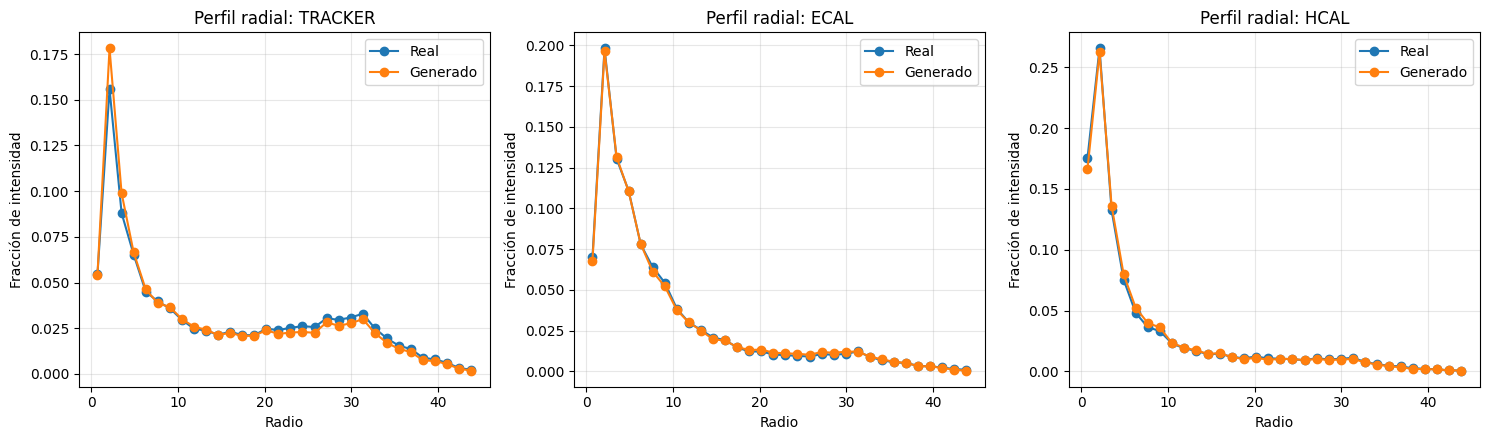

In [123]:
plot_radial_profiles_from_diagnostics(comparison_diagnostics)

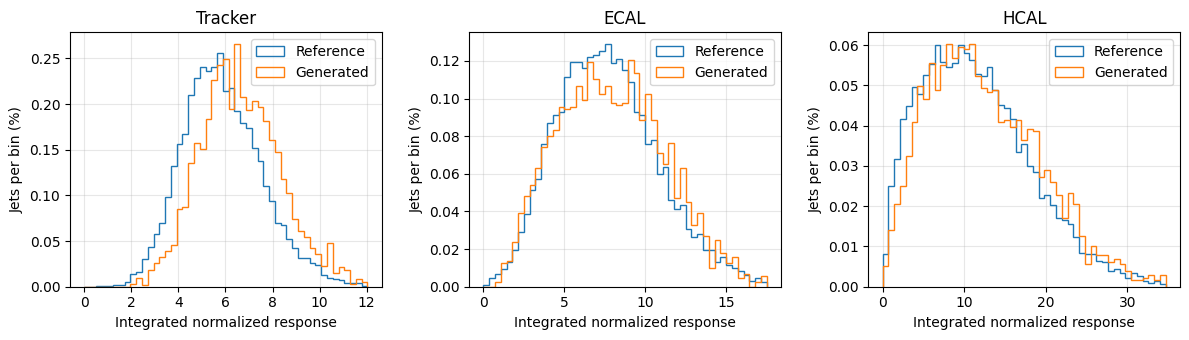

In [124]:
import numpy as np
import matplotlib.pyplot as plt
channel_names = ['Tracker', 'ECAL', 'HCAL']
real_response = real_diag['energy']
gen_response = gen_diag['energy']
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for k, ax in enumerate(axes):
    real_k = real_response[:, k]
    gen_k = gen_response[:, k]
    max_value = max(np.quantile(real_k, 0.995), np.quantile(gen_k, 0.995))
    bins = np.linspace(0, max_value, 50)
    ax.hist(real_k, bins=bins, histtype='step', density=True, label='Reference')
    ax.hist(gen_k, bins=bins, histtype='step', density=True, label='Generated')
    ax.set_title(channel_names[k])
    ax.set_xlabel('Integrated normalized response')
    ax.set_ylabel('Jets per bin (%)')
    ax.grid(True, which='major', axis='both', alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig('response_distributions.pdf', bbox_inches='tight')
plt.show()

In [125]:
def plot_real_vs_generated_class_separation(
    real_diag, generated_diag, real_labels, generated_labels, metric, num_bins=50, upper_quantile=0.999,
    class_0_name='Class 0', class_1_name='Class 1',
):
    real_labels_np = torch.as_tensor(real_labels).long().cpu().numpy().reshape(-1)
    generated_labels_np = torch.as_tensor(generated_labels).long().cpu().numpy().reshape(-1)
    if metric == 'energy':
        real_data = np.asarray(real_diag['energy'])
        generated_data = np.asarray(generated_diag['energy'])
        title_prefix = 'Integrated energy'
        x_label = 'Sum of normalized intensities'
    elif metric == 'active_fraction':
        real_data = np.asarray(real_diag['active_fraction']) * 100.0
        generated_data = np.asarray(generated_diag['active_fraction']) * 100.0
        title_prefix = 'Active fraction'
        x_label = 'Active pixels per jet (%)'
    elif metric == 'maximum':
        real_data = np.asarray(real_diag['maximum'])
        generated_data = np.asarray(generated_diag['maximum'])
        title_prefix = 'Maximum intensity'
        x_label = 'Normalized maximum intensity'
    else:
        raise ValueError("metric debe ser 'energy', 'active_fraction' o 'maximum'.")
    if real_data.ndim != 2:
        raise ValueError('real_data debe tener shape [N, C].')
    if generated_data.ndim != 2:
        raise ValueError('generated_data debe tener shape [N, C].')
    real_mask_0 = real_labels_np == 0
    real_mask_1 = real_labels_np == 1
    generated_mask_0 = generated_labels_np == 0
    generated_mask_1 = generated_labels_np == 1
    if real_mask_0.sum() == 0 or real_mask_1.sum() == 0:
        raise ValueError('El conjunto real no contiene ambas clases.')
    if generated_mask_0.sum() == 0 or generated_mask_1.sum() == 0:
        raise ValueError('El conjunto generado no contiene ambas clases.')
    print(f'REAL -> {class_0_name}: {real_mask_0.sum()} | {class_1_name}: {real_mask_1.sum()}')
    print(f'GENERATED -> {class_0_name}: {generated_mask_0.sum()} | {class_1_name}: {generated_mask_1.sum()}')
    fig, axes = plt.subplots(2, len(CHANNEL_NAMES), figsize=(16, 9), sharey='row')
    for channel, channel_name in enumerate(CHANNEL_NAMES):
        real_values_0 = real_data[real_mask_0, channel]
        real_values_1 = real_data[real_mask_1, channel]
        bins_real = common_histogram_bins(real_values_0, real_values_1, num_bins=num_bins, upper_quantile=upper_quantile)
        real_weights_0 = np.full(real_values_0.shape, 100.0 / len(real_values_0))
        real_weights_1 = np.full(real_values_1.shape, 100.0 / len(real_values_1))
        axes[0, channel].hist(real_values_0, bins=bins_real, weights=real_weights_0, histtype='step', linewidth=2, label=class_0_name)
        axes[0, channel].hist(real_values_1, bins=bins_real, weights=real_weights_1, histtype='step', linewidth=2, label=class_1_name)
        axes[0, channel].set_title(f'REAL — {title_prefix}: {channel_name}')
        axes[0, channel].set_xlabel(x_label)
        axes[0, channel].set_ylabel('Jets (%)')
        axes[0, channel].legend()
        axes[0, channel].grid(alpha=0.3)
        generated_values_0 = generated_data[generated_mask_0, channel]
        generated_values_1 = generated_data[generated_mask_1, channel]
        bins_generated = common_histogram_bins(generated_values_0, generated_values_1, num_bins=num_bins, upper_quantile=upper_quantile)
        generated_weights_0 = np.full(generated_values_0.shape, 100.0 / len(generated_values_0))
        generated_weights_1 = np.full(generated_values_1.shape, 100.0 / len(generated_values_1))
        axes[1, channel].hist(generated_values_0, bins=bins_generated, weights=generated_weights_0, histtype='step', linewidth=2, label=class_0_name)
        axes[1, channel].hist(generated_values_1, bins=bins_generated, weights=generated_weights_1, histtype='step', linewidth=2, label=class_1_name)
        axes[1, channel].set_title(f'GENERATED — {title_prefix}: {channel_name}')
        axes[1, channel].set_xlabel(x_label)
        axes[1, channel].set_ylabel('Jets (%)')
        axes[1, channel].legend()
        axes[1, channel].grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
    return (fig, axes)

REAL -> Class 0: 6923 | Class 1: 7009
GENERATED -> Class 0: 1240 | Class 1: 1260


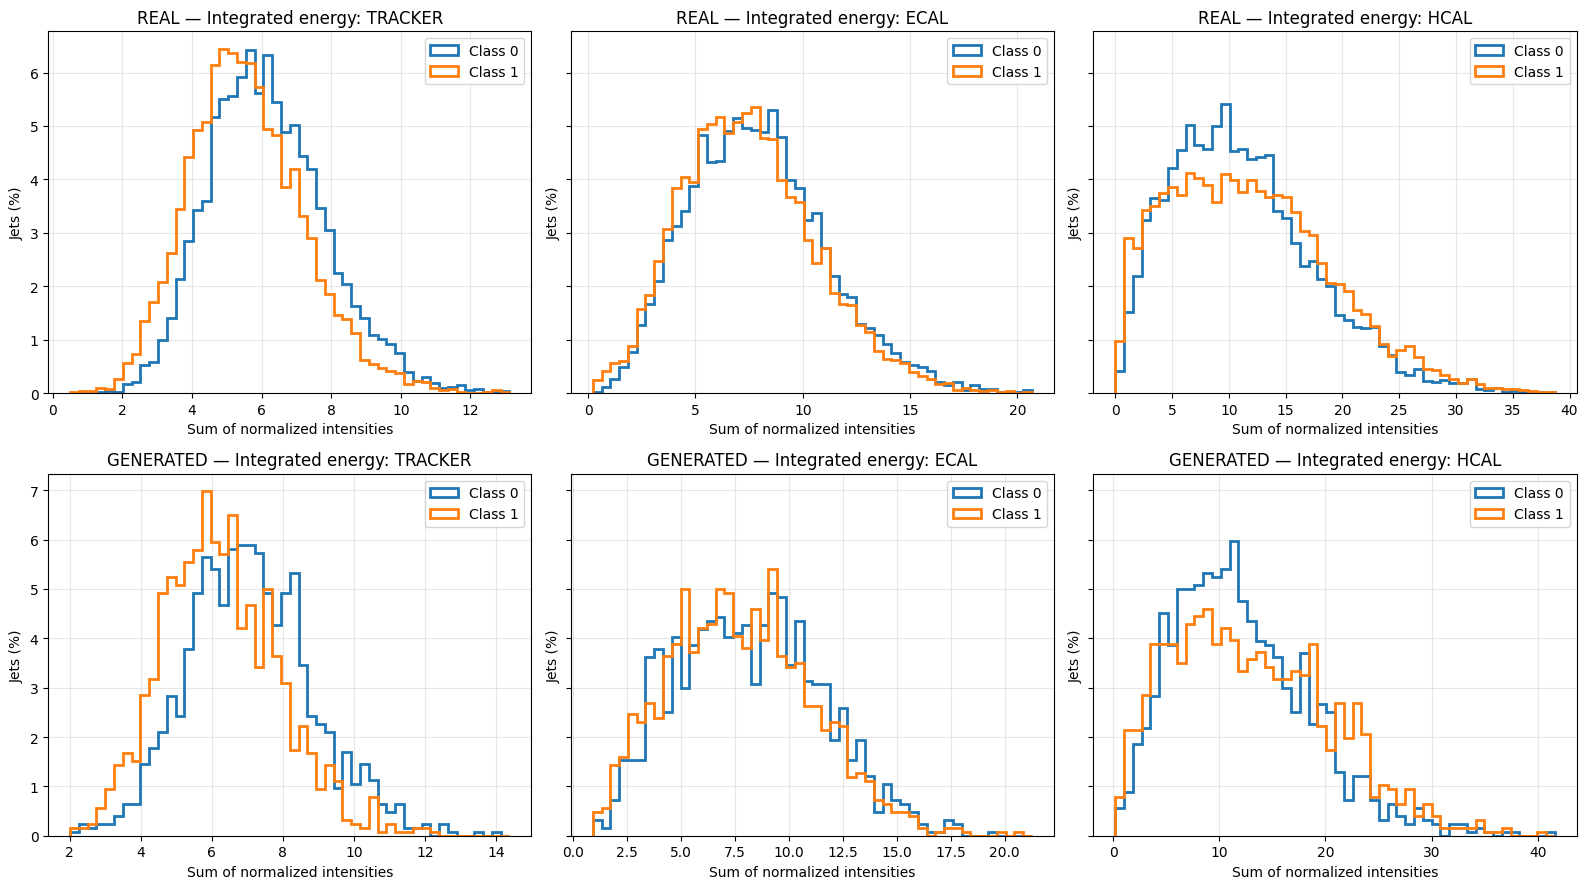

(<Figure size 1600x900 with 6 Axes>,
 array([[<Axes: title={'center': 'REAL — Integrated energy: TRACKER'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Integrated energy: ECAL'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Integrated energy: HCAL'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>],
        [<Axes: title={'center': 'GENERATED — Integrated energy: TRACKER'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Integrated energy: ECAL'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Integrated energy: HCAL'}, xlabel='Sum of normalized intensities', ylabel='Jets (%)'>]],
       dtype=object))

In [126]:
plot_real_vs_generated_class_separation(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, metric='energy', num_bins=50, upper_quantile=0.999,
    class_0_name='Class 0', class_1_name='Class 1',
)

REAL -> Class 0: 6923 | Class 1: 7009
GENERATED -> Class 0: 1240 | Class 1: 1260


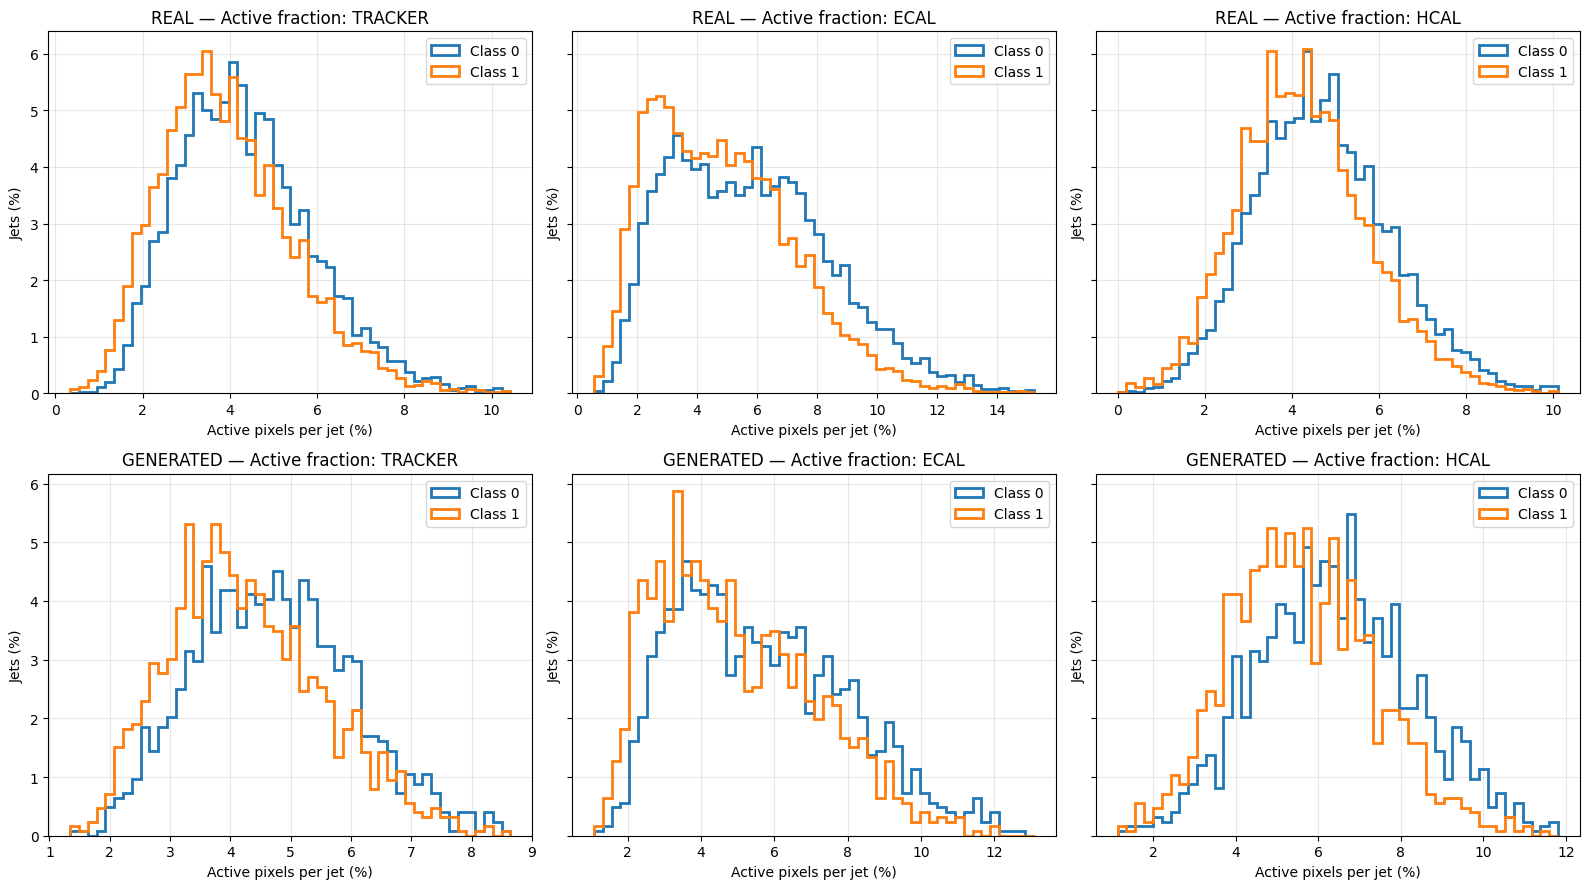

(<Figure size 1600x900 with 6 Axes>,
 array([[<Axes: title={'center': 'REAL — Active fraction: TRACKER'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Active fraction: ECAL'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Active fraction: HCAL'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>],
        [<Axes: title={'center': 'GENERATED — Active fraction: TRACKER'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Active fraction: ECAL'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Active fraction: HCAL'}, xlabel='Active pixels per jet (%)', ylabel='Jets (%)'>]],
       dtype=object))

In [127]:
plot_real_vs_generated_class_separation(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, metric='active_fraction', num_bins=50, upper_quantile=0.999,
    class_0_name='Class 0', class_1_name='Class 1',
)

REAL -> Class 0: 6923 | Class 1: 7009
GENERATED -> Class 0: 1240 | Class 1: 1260


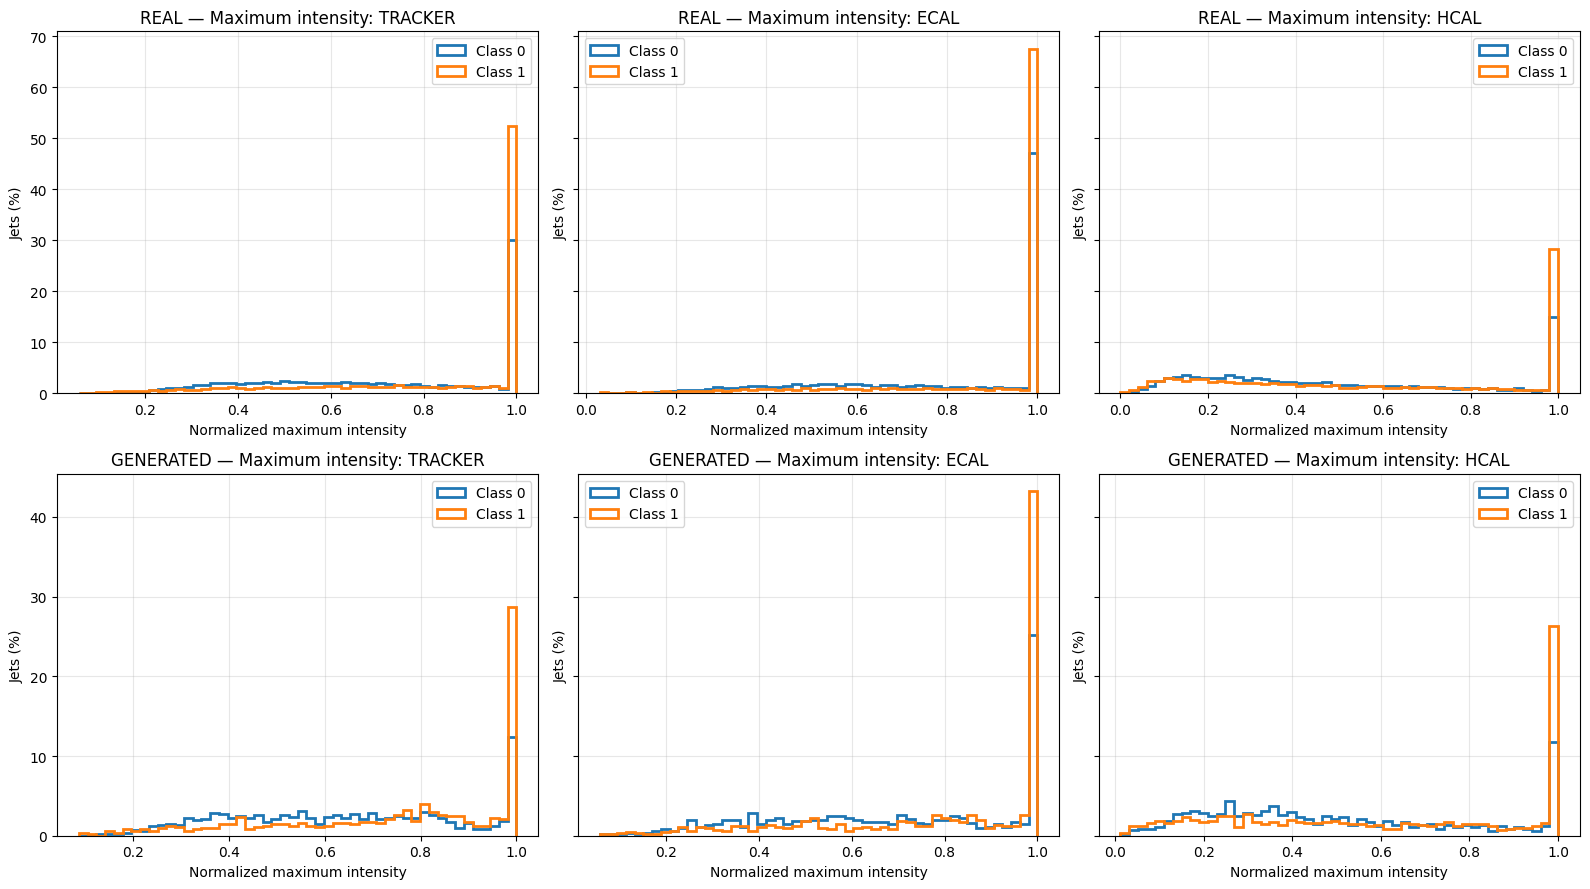

(<Figure size 1600x900 with 6 Axes>,
 array([[<Axes: title={'center': 'REAL — Maximum intensity: TRACKER'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Maximum intensity: ECAL'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>,
         <Axes: title={'center': 'REAL — Maximum intensity: HCAL'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>],
        [<Axes: title={'center': 'GENERATED — Maximum intensity: TRACKER'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Maximum intensity: ECAL'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>,
         <Axes: title={'center': 'GENERATED — Maximum intensity: HCAL'}, xlabel='Normalized maximum intensity', ylabel='Jets (%)'>]],
       dtype=object))

In [128]:
plot_real_vs_generated_class_separation(
    real_diag=real_diag, generated_diag=gen_diag, real_labels=ldm_test_labels,
    generated_labels=generated_labels_2500, metric='maximum', num_bins=50, upper_quantile=0.999,
    class_0_name='Class 0', class_1_name='Class 1',
)

In [129]:
@torch.no_grad()
def reconstruct_dataset_with_vae_hard(vae_model, data_loader, device=device):
    vae_model.eval()
    reconstruction_batches = []
    for images, _ in tqdm(data_loader, desc='Reconstruyendo test con VAE'):
        images = images.to(device, non_blocking=True)
        mu, _ = vae_model.encode(images)
        reconstruction_m11 = vae_model.decode_hard(mu)
        reconstruction_01 = ((reconstruction_m11 + 1.0) / 2.0).clamp(0.0, 1.0)
        reconstruction_batches.append(reconstruction_01.detach().cpu())
    return torch.cat(reconstruction_batches, dim=0)

In [130]:
vae_reconstructed_test_01 = reconstruct_dataset_with_vae_hard(vae_model=vae_model, data_loader=test_loader, device=device)
print('Shape:', vae_reconstructed_test_01.shape)

Reconstruyendo test con VAE:   0%|          | 0/871 [00:00<?, ?it/s]

Shape: torch.Size([13932, 3, 64, 64])


In [131]:
vae_diag = collect_image_diagnostics(vae_reconstructed_test_01, active_thr_01=0.0001, num_radial_bins=32)

In [132]:
def compare_real_vae_ldm(real_diag, vae_diag, ldm_diag):
    rows = []
    for channel, channel_name in enumerate(CHANNEL_NAMES):
        energy_real = real_diag['energy'][:, channel]
        energy_vae = vae_diag['energy'][:, channel]
        energy_ldm = ldm_diag['energy'][:, channel]
        active_real = real_diag['active_fraction'][:, channel]
        active_vae = vae_diag['active_fraction'][:, channel]
        active_ldm = ldm_diag['active_fraction'][:, channel]
        maximum_real = real_diag['maximum'][:, channel]
        maximum_vae = vae_diag['maximum'][:, channel]
        maximum_ldm = ldm_diag['maximum'][:, channel]
        radial_real = real_diag['radial_profile'][channel]
        radial_vae = vae_diag['radial_profile'][channel]
        radial_ldm = ldm_diag['radial_profile'][channel]
        energy_real_mean = energy_real.mean()
        rows.append({
            'Canal': channel_name,
            'E real': energy_real_mean,
            'E VAE': energy_vae.mean(),
            'E LDM': energy_ldm.mean(),
            'Bias E VAE (%)': 100.0 * (energy_vae.mean() - energy_real_mean) / max(energy_real_mean, 1e-12),
            'Bias E LDM (%)': 100.0 * (energy_ldm.mean() - energy_real_mean) / max(energy_real_mean, 1e-12),
            'W1 E VAE': wasserstein_distance(energy_real, energy_vae),
            'W1 E LDM': wasserstein_distance(energy_real, energy_ldm),
            'Activa real': active_real.mean(),
            'Activa VAE': active_vae.mean(),
            'Activa LDM': active_ldm.mean(),
            'Máximo real': maximum_real.mean(),
            'Máximo VAE': maximum_vae.mean(),
            'Máximo LDM': maximum_ldm.mean(),
            'W1 máximo VAE': wasserstein_distance(maximum_real, maximum_vae),
            'W1 máximo LDM': wasserstein_distance(maximum_real, maximum_ldm),
            'Radial L2 VAE': np.sqrt(np.mean((radial_vae - radial_real) ** 2)),
            'Radial L2 LDM': np.sqrt(np.mean((radial_ldm - radial_real) ** 2)),
        })
    return pd.DataFrame(rows)

In [133]:
comparison_real_vae_ldm = compare_real_vae_ldm(real_diag=real_diag, vae_diag=vae_diag, ldm_diag=gen_diag)
display(comparison_real_vae_ldm.round(6))

,Canal,E real,E VAE,E LDM,Bias E VAE (%),Bias E LDM (%),W1 E VAE,W1 E LDM,Activa real,Activa VAE,Activa LDM,Máximo real,Máximo VAE,Máximo LDM,W1 máximo VAE,W1 máximo LDM,Radial L2 VAE,Radial L2 LDM
0,TRACKER,5.903112,6.023866,6.678690,2.045603,13.138459,0.121975,0.806576,0.041582,0.041527,0.044881,0.761202,0.774404,0.691925,0.013669,0.069394,0.002223,0.004695
1,ECAL,7.761820,8.247360,8.000010,6.255497,3.068735,0.489392,0.328590,0.053231,0.053251,0.053192,0.827062,0.832656,0.736486,0.006104,0.090616,0.000510,0.001072
2,HCAL,11.560102,11.486446,12.708732,-0.637158,9.936151,0.083496,1.148630,0.044967,0.045005,0.060192,0.528693,0.533676,0.553034,0.005334,0.028854,0.000506,0.002313


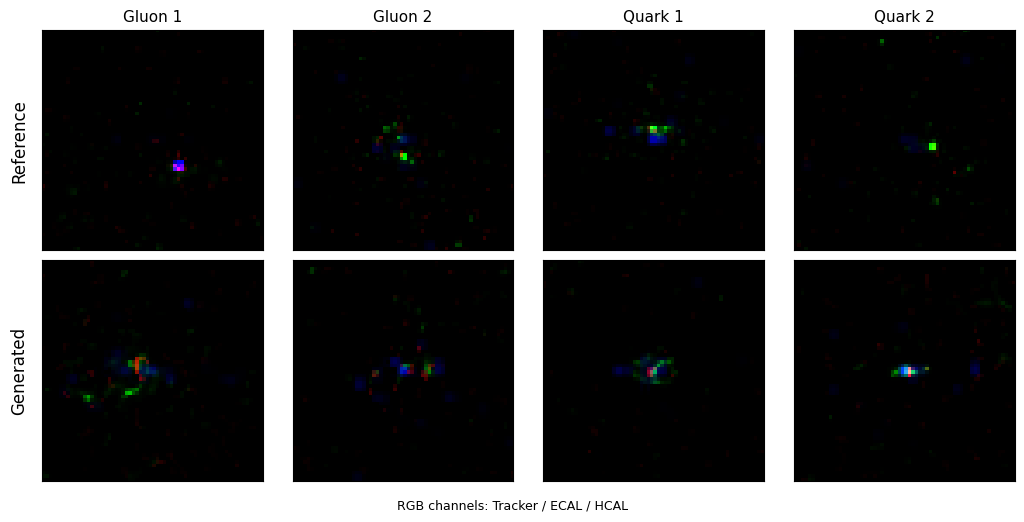

Reference indices: [ 1200 10725  6123  6054]
Generated indices: [1718  202  243 1360]

Figura guardada en:
figures/generated_examples.pdf
figures/generated_examples.png


In [137]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
FIGURE_SEED = 42
rng = np.random.default_rng(FIGURE_SEED)
real_labels_np = torch.as_tensor(ldm_test_labels).long().cpu().numpy().reshape(-1)
generated_labels_np = torch.as_tensor(generated_labels_2500).long().cpu().numpy().reshape(-1)
real_gluon_indices = rng.choice(np.flatnonzero(real_labels_np == 0), size=2, replace=False)
real_quark_indices = rng.choice(np.flatnonzero(real_labels_np == 1), size=2, replace=False)
generated_gluon_indices = rng.choice(np.flatnonzero(generated_labels_np == 0), size=2, replace=False)
generated_quark_indices = rng.choice(np.flatnonzero(generated_labels_np == 1), size=2, replace=False)
real_indices = np.concatenate([real_gluon_indices, real_quark_indices])
generated_indices = np.concatenate([generated_gluon_indices, generated_quark_indices])
real_examples = real_test_images_01[real_indices].detach().float().cpu()
generated_examples = generated_images_01[generated_indices].detach().float().cpu()
DISPLAY_GAMMA = 0.8

def prepare_rgb(image):
    image = image.permute(1, 2, 0).numpy()
    image = np.clip(image, 0.0, 1.0)
    image = image ** DISPLAY_GAMMA
    return image
fig, axes = plt.subplots(2, 4, figsize=(10.5, 5.2))
column_titles = ['Gluon 1', 'Gluon 2', 'Quark 1', 'Quark 2']
for column in range(4):
    axes[0, column].imshow(prepare_rgb(real_examples[column]))
    axes[0, column].set_title(column_titles[column], fontsize=11)
    axes[0, column].set_xticks([])
    axes[0, column].set_yticks([])
    axes[1, column].imshow(prepare_rgb(generated_examples[column]))
    axes[1, column].set_xticks([])
    axes[1, column].set_yticks([])
axes[0, 0].set_ylabel('Reference', fontsize=12, labelpad=10)
axes[1, 0].set_ylabel('Generated', fontsize=12, labelpad=10)
fig.text(0.5, 0.015, 'RGB channels: Tracker / ECAL / HCAL', ha='center', fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 1])
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/generated_examples.pdf', bbox_inches='tight')
plt.savefig('figures/generated_examples.png', dpi=300, bbox_inches='tight')
plt.show()
print('Reference indices:', real_indices)
print('Generated indices:', generated_indices)
print('\nFigura guardada en:')
print('figures/generated_examples.pdf')
print('figures/generated_examples.png')